# Import libraries and data

## Libraries and functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import geopandas as gpd
import networkx as nx
import csv
import xml.etree.ElementTree as ET
from scipy.spatial import KDTree
from scipy.spatial import cKDTree
import pickle
import folium
from shapely.geometry import LineString
from shapely.geometry import box
import contextily as ctx


from Tool import clean_speed, fill_tracks, clean_elec, from_df_to_geodf, neighbour_gauge, final_gauge, haversine_distance, is_important_component

## Inputs

In [2]:
#Change inputs here if needed
rail_data = "data/uk_railways_osm.gpkg"
Train_Planning_file = "data/TrainPlanningRules.xml"
Stops = "data/Stops.csv"
loading_gauge = "data/loading_gauge.geojson"
nodes_file = "nodes.csv"
STANOX_TIPLOC = "data/STANOX_TIPLOC.csv"

## Import of the datasets and conversion into a csv file

In [3]:
gdf = gpd.read_file(rail_data)

gdf['geometry_wkt'] = gdf['geometry'].apply(lambda x: x.wkt)

gdf['start_lon'] = gdf['geometry'].apply(lambda x: x.coords[0][0])
gdf['start_lat'] = gdf['geometry'].apply(lambda x: x.coords[0][1])
gdf['end_lon'] = gdf['geometry'].apply(lambda x: x.coords[-1][0])
gdf['end_lat'] = gdf['geometry'].apply(lambda x: x.coords[-1][1])

if 'other_tags' in gdf.columns:
    gdf['other_tags'] = gdf['other_tags'].astype(str)

#Not compatible with geopandas
df_rail = pd.DataFrame(gdf.drop(columns=['geometry']))

df_rail.to_csv("complete_railway_network.csv", index=False, sep=';', encoding='utf-8')

## Clean this dataset

In [4]:
df_rail = df_rail[df_rail['railway'].isin(['rail', 'service', 'yard', 'siding', 'industrial', 'disused'])]

### Clean speed format and fill missing values with 60 mph.

In [5]:
df_rail = clean_speed(df_rail)

### Here, we consider to fill the branch or industrial types with 1 track, the others with 2 tracks.

In [6]:
df_rail = fill_tracks(df_rail)
df_rail["tracks"] = df_rail["tracks"].astype(int)

### We will simplify different type of electrification

In [7]:
df_rail['elec_type'] = df_rail.apply(clean_elec, axis=1)

In [8]:
df_rail.columns

Index(['osm_id', 'name', 'highway', 'waterway', 'aerialway', 'barrier',
       'man_made', 'railway', 'usage', 'electrified', 'frequency', 'gauge',
       'maxspeed', 'operator', 'railway_aws', 'railway_tpws', 'ref', 'voltage',
       'layer', 'tracks', 'passenger_lines', 'foot', 'lit', 'segregated',
       'smoothness', 'surface', 'width', 'bicycle', 'z_order', 'other_tags',
       'geometry_wkt', 'start_lon', 'start_lat', 'end_lon', 'end_lat',
       'elec_type'],
      dtype='object')

In [9]:
to_drop = [
    "highway", "waterway", "aerialway", "barrier", "man_made",
    "railway_aws", "railway_tpws", "ref", "layer", "foot", "lit",
    "segregated", "smoothness", "surface", "width", "bicycle",
    "z_order", "other_tags"
]

df_rail = df_rail.drop(columns=[c for c in to_drop if c in df_rail.columns])

In [10]:
print("\n Stats for 'electrified':")
print(df_rail['electrified'].value_counts(dropna=False))


 Stats for 'electrified':
electrified
no                       43896
contact_line             26848
rail                     13110
None                      8157
4th_rail                   283
proposed                   242
contact_line;rail          157
contact_line;4th_rail        9
yes                          4
0                            1
construction                 1
Name: count, dtype: int64


In [11]:
df_rail.head()

,osm_id,name,railway,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,passenger_lines,geometry_wkt,start_lon,start_lat,end_lon,end_lat,elec_type
0,740,Cross-City Line,rail,branch,contact_line,50,1435,45.0,Network Rail,25000,1,None,"LINESTRING (-1.8178905 52.5700974, -1.8179287 ...",-1.817891,52.570097,-1.822176,52.565950,Overhead
1,2148,Cross-City Line,rail,branch,contact_line,50,1435,45.0,Network Rail,25000,1,None,"LINESTRING (-1.873028 52.5054182, -1.8726964 5...",-1.873028,52.505418,-1.871725,52.504113,Overhead
3,3413,North Clyde Line,rail,main,contact_line,50,1435,50.0,Network Rail,25000,2,2,"LINESTRING (-4.3258776 55.8827209, -4.3255873 ...",-4.325878,55.882721,-4.323074,55.882447,Overhead
4,3417,North Clyde Line,rail,main,contact_line,50,1435,40.0,Network Rail,25000,2,2,"LINESTRING (-4.3138852 55.8776742, -4.3139865 ...",-4.313885,55.877674,-4.310577,55.870938,Overhead
5,3471,Midland Main Line,rail,main,contact_line,50,1435,90.0,Network Rail,25000,1,4,"LINESTRING (-0.4950811 51.9681192, -0.4951938 ...",-0.495081,51.968119,-0.495194,51.963738,Overhead


In [12]:
print("Values in 'tracks':")
print(df_rail['tracks'].unique())
print(df_rail['tracks'].value_counts(dropna=False))

Values in 'tracks':
[1 2 4 5 6 3]
tracks
2    67897
1    23266
4     1144
6      301
3       51
5       49
Name: count, dtype: int64


In [13]:
len(df_rail)

92708

# Cleaning of the dataset

## Load the loading gauge dataset

In [14]:
#Load datasets

gdf_rail = from_df_to_geodf(df_rail)
gdf_loading_gauge = gpd.read_file(loading_gauge)

#Join and check the neighbours to apply to missing loading gauges
df_complete = neighbour_gauge(gdf_rail, gdf_loading_gauge)

#If no neighboutrs, check the voltage to find the loading gauge
df_complete['loading_gauge_final'] = df_complete.apply(final_gauge, axis=1)

#Spread of different loading gauges
print(df_complete['loading_gauge_final'].value_counts())

c:\Users\Administrateur\Documents\3A\Internship\resilience_freight_train_UK\Tool.py:92: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  unknown['geom_buffer'] = unknown.geometry.buffer(0.00001)


loading_gauge_final
6.0     51062
10.0    26553
7.0     12538
8.0      1590
12.0      790
1.0       117
9.0        58
Name: count, dtype: int64


## Clean this datset

### Outliers : there are "W1" gauges that need to be removed

In [15]:
#We replace these W1 values by W6 values
df_complete.loc[df_complete['loading_gauge_final'] < 6, 'loading_gauge_final'] = 6
print(df_complete['loading_gauge_final'].value_counts().sort_index())

df_complete.to_csv("Final_dataframe_rail.csv", index=False)

loading_gauge_final
6.0     51179
7.0     12538
8.0      1590
9.0        58
10.0    26553
12.0      790
Name: count, dtype: int64


In [16]:
df_complete = df_complete.drop(columns=['railway', 'index_right', 'loading_gauge_val'])

## Add the distance between two nodes

In [17]:
df_complete['distance'] = haversine_distance(df_complete["start_lat"],df_complete["start_lon"],df_complete["end_lat"],df_complete["end_lon"])
df_complete['min_travel_time'] = df_complete['distance'] / df_complete['maxspeed']

In [18]:
df_complete.head()

,osm_id,name,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,...,geometry_wkt,start_lon,start_lat,end_lon,end_lat,elec_type,geometry,loading_gauge_final,distance,min_travel_time
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,"LINESTRING (-1.8178905 52.5700974, -1.8179287 ...",-1.817891,52.570097,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,"LINESTRING (-1.873028 52.5054182, -1.8726964 5...",-1.873028,52.505418,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346
3,3413,North Clyde Line,main,contact_line,50,1435,50.0,Network Rail,25000,2,...,"LINESTRING (-4.3258776 55.8827209, -4.3255873 ...",-4.325878,55.882721,-4.323074,55.882447,Overhead,"LINESTRING (-4.32588 55.88272, -4.32559 55.882...",10.0,0.110298,0.002206
4,3417,North Clyde Line,main,contact_line,50,1435,40.0,Network Rail,25000,2,...,"LINESTRING (-4.3138852 55.8776742, -4.3139865 ...",-4.313885,55.877674,-4.310577,55.870938,Overhead,"LINESTRING (-4.31389 55.87767, -4.31399 55.876...",10.0,0.482767,0.012069
5,3471,Midland Main Line,main,contact_line,50,1435,90.0,Network Rail,25000,1,...,"LINESTRING (-0.4950811 51.9681192, -0.4951938 ...",-0.495081,51.968119,-0.495194,51.963738,Overhead,"LINESTRING (-0.49508 51.96812, -0.49519 51.96374)",10.0,0.302781,0.003364


## Upload a file with names for train stations

In [19]:
with open(nodes_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "tiploc", "name"])

    for event, elem in ET.iterparse(Train_Planning_file, events=("end",)):
        if elem.tag == "TTPRLocation":
            
            writer.writerow([
                elem.attrib.get("Id"),
                elem.attrib.get("Tiploc"),
                elem.attrib.get("Description")
            ])
            
            elem.clear()

## Clean this dataset

In [20]:
df_nodes = pd.read_csv(nodes_file)

#Delete row without ID
df_nodes = df_nodes.dropna(subset=['id'])
df_nodes = df_nodes.drop_duplicates()

#Clean the str and make sure any blank space is there
df_nodes['tiploc'] = df_nodes['tiploc'].astype(str).str.strip()
df_nodes['name'] = df_nodes['name'].astype(str).str.strip()

invalid_values = ["unknown", "none", "nan"]

df_nodes = df_nodes[
    ~df_nodes.drop(columns=["id"])
      .apply(lambda col: col.astype(str).str.strip().str.lower())
      .isin(invalid_values)
      .all(axis=1)
]


df_nodes.to_csv("nodes_clean.csv", index=False)

print("Number of remaining nodes: ", len(df_nodes))

Number of remaining nodes:  12107


In [21]:
df_nodes.head()

,id,tiploc,name
2,3.0,AACHEN,Aachen
3,4.0,ABCWM,Abercwmboi
4,5.0,ABDAPEN,Penywaun
5,6.0,ABDARE,Aberdare
6,7.0,ABDATRE,Trecynon


## Load datsaset with locations and merge with the names dataset

In [22]:
df_lon_lat = pd.read_csv("data/stations.csv")

print("Number of nodes remaining (nodes) : ", len(df_nodes))
print("Number of nodes remaining (lon_lat) : ", len(df_lon_lat))

df_name_loc = pd.merge(
    df_nodes, 
    df_lon_lat, 
    left_on='name', 
    right_on='stationName', 
    how='left'
)

df_name_loc.head(10)

Number of nodes remaining (nodes) :  12107
Number of nodes remaining (lon_lat) :  2605


,id,tiploc,name,stationName,lat,long,crsCode,iataAirportCode,constituentCountry
0,3.0,AACHEN,Aachen,NaN,NaN,NaN,NaN,NaN,NaN
1,4.0,ABCWM,Abercwmboi,NaN,NaN,NaN,NaN,NaN,NaN
2,5.0,ABDAPEN,Penywaun,NaN,NaN,NaN,NaN,NaN,NaN
3,6.0,ABDARE,Aberdare,Aberdare,51.715019,-3.443130,ABA,NaN,wales
4,7.0,ABDATRE,Trecynon,NaN,NaN,NaN,NaN,NaN,NaN
5,8.0,ABDO,Aberdour,Aberdour,56.054646,-3.300575,AUR,NaN,scotland
6,9.0,ABDVY,Aberdovey,Aberdovey,52.543934,-4.057118,AVY,NaN,wales
7,10.0,ABER,Aber,Aber,51.575363,-3.230890,ABE,NaN,wales
8,11.0,ABGLELE,Abergele & Pensarn,Abergele & Pensarn,53.294758,-3.581343,AGL,NaN,wales
9,12.0,ABGNWYN,Abergynolwyn,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
print(len(df_name_loc))
df_name_loc = df_name_loc.drop(columns=['stationName', 'iataAirportCode', 'constituentCountry'])

12107


In [24]:
df_name_loc.head()

,id,tiploc,name,lat,long,crsCode
0,3.0,AACHEN,Aachen,NaN,NaN,NaN
1,4.0,ABCWM,Abercwmboi,NaN,NaN,NaN
2,5.0,ABDAPEN,Penywaun,NaN,NaN,NaN
3,6.0,ABDARE,Aberdare,51.715019,-3.44313,ABA
4,7.0,ABDATRE,Trecynon,NaN,NaN,NaN


## Add the Engineer Line Reference (ELR) in order to identify easily the line

In [25]:
elr = gpd.read_file("data/ELR/NetworkReferenceLines.shp")
elr_buff = elr.to_crs(4326).copy()
elr_buff["geometry"] = elr_buff.geometry.buffer(0.0001)
elr


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_26168\2230585469.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  elr_buff["geometry"] = elr_buff.geometry.buffer(0.0001)


,OBJECTID,ASSETID,L_LINK_ID,L_SYSTEM,ELR,L_M_FROM,L_M_TO,SHAPE_LEN,geometry
0,1650,9003000263,232,M,CNC,-0.0055,0.0891,899.318917,"LINESTRING Z (258538.418 661238.192 0, 258545...."
1,1651,9003001307,1191,M,WCL,0.1758,2.1706,3170.461977,"LINESTRING Z (521077.898 183246.059 0, 521052...."
2,1652,9003001178,1076,M,SSK1,26.1589,39.0242,19691.905626,"LINESTRING Z (465068.728 521387.373 0, 465077...."
3,1653,9003001388,1260,M,YJP,-0.0350,1.0954,2797.307199,"LINESTRING Z (356982.337 114059.032 0, 356989...."
4,1654,9003000952,873,M,PEH,0.0849,13.0960,21015.381545,"LINESTRING Z (413793.018 416380.012 0, 413729...."
...,...,...,...,...,...,...,...,...,...
1585,5131,9003001637,1694,M,GRC1,-0.0068,0.0723,732.035182,"LINESTRING Z (441392.094 406550.649 0, 441449...."
1586,5132,9003001623,1680,M,CMP,188.0727,188.1215,446.568578,"LINESTRING Z (385412.469 397552.006 0, 385361...."
1587,5133,9003001609,1718,M,RET,-0.0016,0.0927,863.140513,"LINESTRING Z (193288.191 59949.545 0, 193314.5..."
1588,5134,9003001618,1673,M,SWX,-0.0012,0.0784,728.586613,"LINESTRING Z (503416.196 172077.673 0, 503378...."


In [26]:
df_final = gpd.sjoin(
    df_complete,
    elr_buff[["ELR", "L_LINK_ID", "geometry"]],
    how="left",
    predicate="intersects"
)

print(df_final["ELR"].isna().mean())

print(df_final.columns)
print(df_name_loc.columns)

0.1499253041189443
Index(['osm_id', 'name', 'usage', 'electrified', 'frequency', 'gauge',
       'maxspeed', 'operator', 'voltage', 'tracks', 'passenger_lines',
       'geometry_wkt', 'start_lon', 'start_lat', 'end_lon', 'end_lat',
       'elec_type', 'geometry', 'loading_gauge_final', 'distance',
       'min_travel_time', 'index_right', 'ELR', 'L_LINK_ID'],
      dtype='object')
Index(['id', 'tiploc', 'name', 'lat', 'long', 'crsCode'], dtype='object')


In [27]:
df_final.to_csv("OSM_cleaned_data.csv", index=False, sep=';', encoding='utf-8')

In [28]:
df_final.head()

,osm_id,name,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,...,end_lon,end_lat,elec_type,geometry,loading_gauge_final,distance,min_travel_time,index_right,ELR,L_LINK_ID
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520,877.0,CBR2,179.0
0,740,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.822176,52.565950,Overhead,"LINESTRING (-1.81789 52.5701, -1.81793 52.5698...",10.0,0.338416,0.007520,750.0,ALC2,19.0
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346,497.0,ALC1,18.0
1,2148,Cross-City Line,branch,contact_line,50,1435,45.0,Network Rail,25000,1,...,-1.871725,52.504113,Overhead,"LINESTRING (-1.87303 52.50542, -1.8727 52.5051...",10.0,0.105548,0.002346,88.0,PBJ,861.0
3,3413,North Clyde Line,main,contact_line,50,1435,50.0,Network Rail,25000,2,...,-4.323074,55.882447,Overhead,"LINESTRING (-4.32588 55.88272, -4.32559 55.882...",10.0,0.110298,0.002206,529.0,YKR,1261.0


# Construction of the graph

In [29]:
G = nx.Graph()

for _, row in df_name_loc.iterrows():

    node_id = row["tiploc"] if pd.notna(row["tiploc"]) else row["id"]

    G.add_node(
        node_id,
        type="station",
        name=row["name"],
        lat=row["lat"],
        lon=row["long"],
        crs=row["crsCode"],
    )

for _, row in df_final.iterrows():

    start = (row.start_lon, row.start_lat)
    end = (row.end_lon, row.end_lat)

    G.add_node(start, type="osm_point", lon=row.start_lon, lat=row.start_lat)
    G.add_node(end, type="osm_point", lon=row.end_lon, lat=row.end_lat)

    G.add_edge(
        start,
        end,
        distance=row["distance"],
        maxspeed=row["maxspeed"],
        loading_gauge=row["loading_gauge_final"],
        electrified=row["elec_type"],
        gauge=row["gauge"],
        tracks=row["tracks"],
        usage=row["usage"],
        elr=row["ELR"]
    )


#We merge the two dataframe into a graph
osm_nodes = np.array([node for node in G.nodes if isinstance(node, tuple)])

for _, row in df_name_loc.iterrows():

    station_id = row["tiploc"] if pd.notna(row["tiploc"]) else row["id"]
    station_point = np.array([row["long"], row["lat"]])

    #We aggregagte the nearest osm node to the tnode station
    dists = np.linalg.norm(osm_nodes - station_point, axis=1)
    nearest = tuple(osm_nodes[np.argmin(dists)])

    G.add_edge(station_id, nearest, type="station_link")


## Add STANOX attributes to the graph

In [30]:
df_STAN_TIP = pd.read_csv("data/STANOX_TIPLOC.csv", sep=",")
df_STAN_TIP["STANOX"] = (
    df_STAN_TIP["STANOX"]
    .astype(str)
    .str.strip()
    .replace("", None)
    .apply(lambda x: x.zfill(5) if x is not None else None)
)

stanox_map = df_STAN_TIP.set_index("TIPLOC")["STANOX"].to_dict()

for n, d in G.nodes(data=True):
    if d.get("type") == "station":
        tiploc = n
        d["stanox"] = stanox_map.get(tiploc)

In [31]:
stations = [n for n, d in G.nodes(data=True) if d.get("type")=="station"]
[(n, G.nodes[n].get("stanox")) for n in stations[:10]]

[('AACHEN', '00005'),
 ('ABCWM', '78128'),
 ('ABDAPEN', None),
 ('ABDARE', '78100'),
 ('ABDATRE', None),
 ('ABDO', '03295'),
 ('ABDVY', '64409'),
 ('ABER', '78371'),
 ('ABGLELE', '40073'),
 ('ABGNWYN', None)]

## Look at the graph attributes

In [32]:
print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())


Nodes : 119337
Edges : 104253


In [33]:
stations = [n for n, d in G.nodes(data=True) if d.get("type") == "station"]
print("Stations :", len(stations))


Stations : 11696


### Check whether some parts are isolated

In [34]:
nx.number_connected_components(G)

16874

In [35]:
distances = [d["distance"] for _,_,d in G.edges(data=True) if "distance" in d]
pd.Series(distances).describe()

count    92556.000000
mean         0.248679
std          0.501591
min          0.000000
25%          0.022690
50%          0.080016
75%          0.252066
max         15.837627
dtype: float64

In [36]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
print("Number of components in the graph :", len(components))
print("Size of the largest component :", len(components[0]))

Number of components in the graph : 16874
Size of the largest component : 73648


## Components to reconnect to the network

In [37]:
#Number of components ordered and with more than 20 nodes
components = list(nx.connected_components(G))
components_sorted = sorted(components, key=len, reverse=True)
components_filtered = [c for c in components_sorted if len(c) >= 20]
print(f"Total number of components : {len(components_sorted)}")

#Main component
main_component = components_filtered[0]
main_coords = np.array([n for n in main_component if isinstance(n, tuple)])
main_tree = KDTree(main_coords)

#Check if each component needs to be kept  or rejected
results = []

for idx, comp in enumerate(components_filtered):
    keep = is_important_component(G, comp, stations, main_coords, main_tree)
    results.append((idx, len(comp), keep))

for idx, size, keep in results:
    status = "KEPT" if keep else "REJECTED"

kept = sum(1 for _,_,k in results if k)
print("\nAfter cleaning, we have kept :", kept, "components")

Total number of components : 16874

After cleaning, we have kept : 86 components


## Distribution of node sizes components

In [38]:
sizes_kept = [len(components_filtered[idx]) 
              for idx, _, keep in results if keep]

print("Min size :", np.min(sizes_kept))
print("Max size :", np.max(sizes_kept))
print("Average size :", np.mean(sizes_kept))

hist = {}
for s in sizes_kept:
    bucket = (s // 20) * 20
    hist[bucket] = hist.get(bucket, 0) + 1

print("\nDistribution of remaining components :")
for k in sorted(hist):
    print(f"{k:3d}–{k+19:3d} : {hist[k]}")

Min size : 20
Max size : 73648
Average size : 909.3953488372093

Distribution of remaining components :
 20– 39 : 57
 40– 59 : 19
 60– 79 : 2
 80– 99 : 1
100–119 : 1
120–139 : 2
160–179 : 1
540–559 : 1
780–799 : 1
73640–73659 : 1


## Adding the disconnected components to the main component and linking them

In [39]:
kept_components = [
    comp for idx, comp in enumerate(components_filtered)
    if results[idx][2]
]

In [40]:
G_clean = nx.Graph()

for comp in kept_components:
    for n in comp:
        if isinstance(n, tuple) and len(n) == 2:
            G_clean.add_node(n, **G.nodes[n])

    for u, v in G.subgraph(comp).edges():
        if isinstance(u, tuple) and isinstance(v, tuple):
            G_clean.add_edge(u, v, **G[u][v])

In [41]:
component_trees = []

for idx, comp in enumerate(kept_components):
    coords = np.array([n for n in comp if isinstance(n, tuple)])
    tree = cKDTree(coords)
    component_trees.append((idx, coords, tree))

In [42]:
connections = []

for i, (idx_i, coords_i, tree_i) in enumerate(component_trees):
    for j, (idx_j, coords_j, tree_j) in enumerate(component_trees):
        if j <= i:
            continue

        dist, pos = tree_i.query(coords_j, k=1)
        min_dist = dist.min()

        if min_dist <= 0.2:
            j_idx = dist.argmin()
            i_idx = pos[j_idx]

            node_i = tuple(coords_i[i_idx])
            node_j = tuple(coords_j[j_idx])

            connections.append((node_i, node_j, min_dist))

In [43]:
G_connected = G_clean.copy()

for node_i, node_j, dist in connections:
    if node_i in G_clean and node_j in G_clean:

        G_connected.add_node(node_i, **G_clean.nodes[node_i])
        G_connected.add_node(node_j, **G_clean.nodes[node_j])

        G_connected.add_edge(
            node_i,
            node_j,
            artificial=True,
            length=dist,
            geometry=LineString([
                (G_clean.nodes[node_i]["lon"], G_clean.nodes[node_i]["lat"]),
                (G_clean.nodes[node_j]["lon"], G_clean.nodes[node_j]["lat"])
            ])
        )


In [44]:
nx.number_connected_components(G_connected)

2

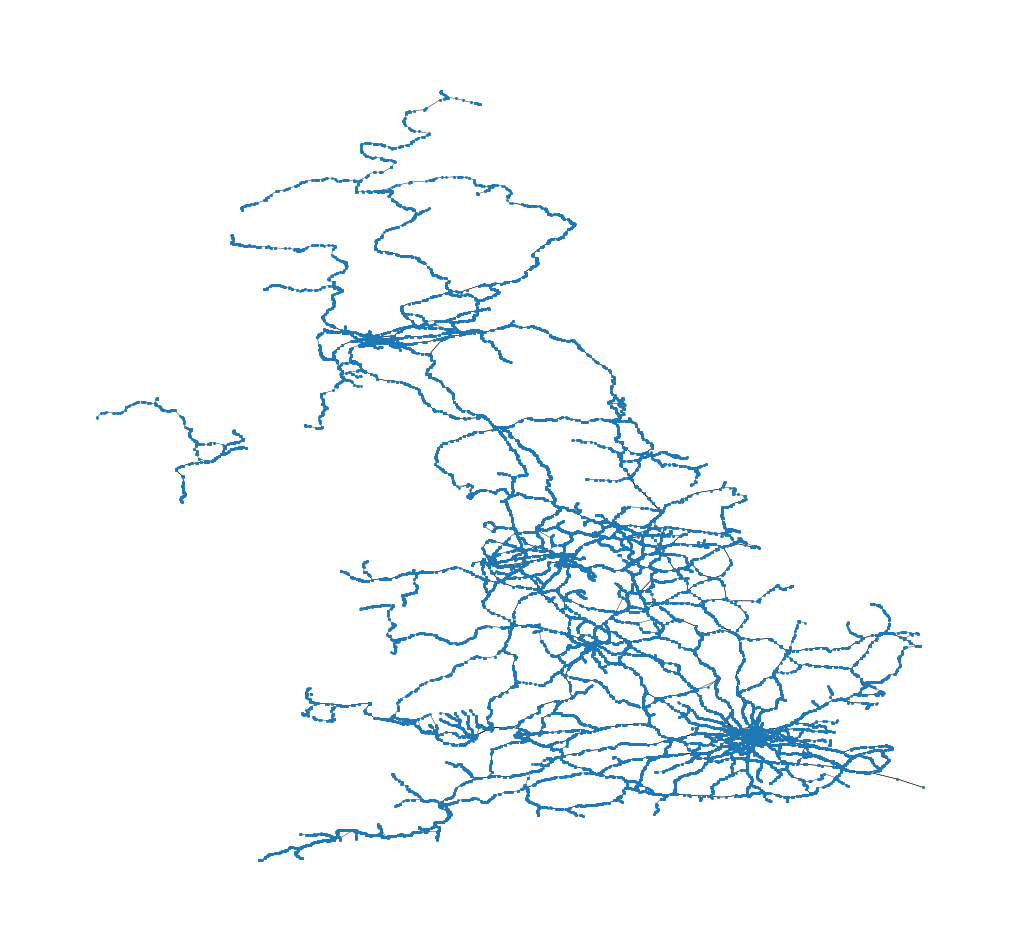

In [45]:
plt.figure(figsize=(10, 12))

pos = {n: (n[0], n[1]) for n in G_connected.nodes()}

nx.draw(
    G_connected,
    pos,
    node_size=1,
    width=0.3,
    edge_color="black"
)

plt.gca().set_aspect("equal")
plt.show()

## We want to remove Northern Ireland because it is not connected to the mainland network in real life

In [46]:
target = np.array([-5.93, 54.60]) #Longitude and latitude of Belfast (Capital of Northern Ireland)

#closest node in the graph
nodes = np.array([np.array(n) for n in G_connected.nodes()])
dists = np.linalg.norm(nodes - target, axis=1)
closest_node = tuple(nodes[dists.argmin()])

print("Closest node is :", closest_node)

#Find and remove the component associated to this point (so removing Northern Ireland)
component_NI = next(comp for comp in nx.connected_components(G_connected) if closest_node in comp)

print("NI component size :", len(component_NI))

G_final = G_connected.copy()
G_final.remove_nodes_from(component_NI)

Closest node is : (-5.9246143, 54.605539)
NI component size : 788


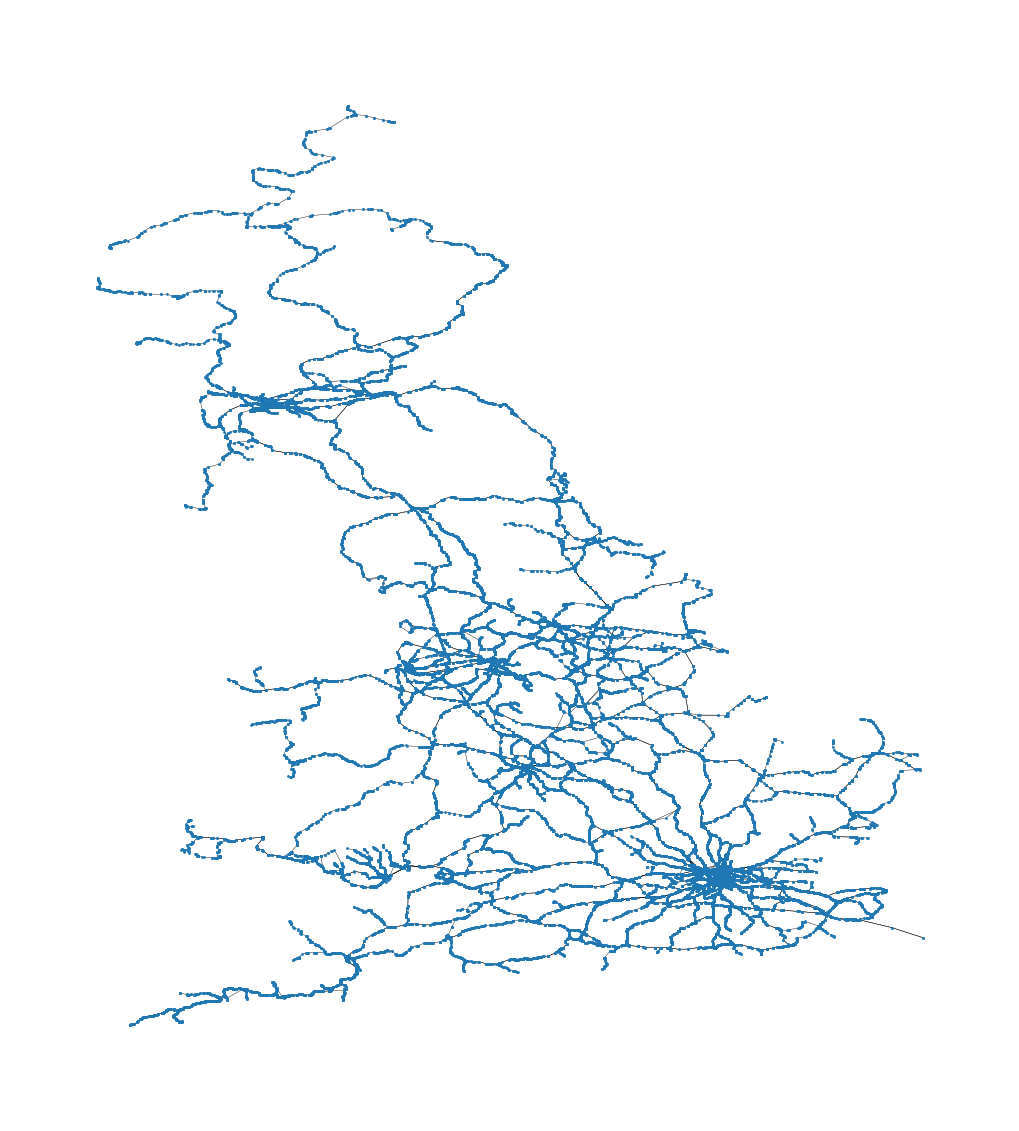

In [47]:
plt.figure(figsize=(10, 12))

pos = {n: (n[0], n[1]) for n in G_final.nodes()}
nx.draw(G_final, pos, node_size=1, width=0.3, edge_color="black")

plt.gca().set_aspect("equal")
plt.show()

In [48]:
m = folium.Map(
    location=[54, -2],
    zoom_start=6,
    tiles="CartoDB Positron"
)

#Add edges
for u, v, d in G_final.edges(data=True):
    if isinstance(u, tuple) and isinstance(v, tuple):
        folium.PolyLine(
            locations=[(u[1], u[0]), (v[1], v[0])],
            color="blue",
            weight=2,
            opacity=0.6
        ).add_to(m)

#Add nodes
for n, d in G_final.nodes(data=True):
    if not (isinstance(n, tuple) and len(n) == 2):
        continue

    lon ,lat = n

    folium.CircleMarker(
        location=[lat, lon],
        radius=1,
        color="red",
        fill=True,
        fill_opacity = 0.5
    ).add_to(m)

m.save("graph.html")
#m

### Is the network now fully connected ? Yes if there is only 1 component

In [49]:
nx.number_connected_components(G_final)

1

### Check the degrees of each node

In [50]:
degrees = [d for _, d in G_final.degree()]
print("min:", np.min(degrees))
print("max:", np.max(degrees))
print("mean:", np.mean(degrees))
print("degree=1:", degrees.count(1))
print("degree=2:", degrees.count(2))
print("degree>=3:", sum(d>=3 for d in degrees))

min: 1
max: 6
mean: 2.0546006983810257
degree=1: 2727
degree=2: 57214
degree>=3: 6212


## Add attributes

In [51]:
stations_in_G = [n for n, d in G.nodes(data=True) if d.get("type") == "station"]
len(stations_in_G)


11696

In [52]:
for n in stations_in_G:
    if n not in G_final:
        G_final.add_node(n)

for n in stations_in_G:
    G_final.nodes[n].update(G.nodes[n])

for n in stations_in_G:
    G_final.nodes[n]["stanox"] = stanox_map.get(n)


In [53]:
[(n, d) for n, d in G_final.nodes(data=True) if isinstance(n, str)][:2]

[('AACHEN',
  {'type': 'station',
   'name': 'Aachen',
   'lat': nan,
   'lon': nan,
   'crs': nan,
   'stanox': '00005'}),
 ('ABCWM',
  {'type': 'station',
   'name': 'Abercwmboi',
   'lat': nan,
   'lon': nan,
   'crs': nan,
   'stanox': '78128'})]

In [54]:
[(n, d) for n, d in G_final.nodes(data=True) if isinstance(n, tuple)][:2]

[((1.1454283, 51.2592228),
  {'type': 'osm_point', 'lon': 1.1454283, 'lat': 51.2592228}),
 ((-2.5807156, 51.4484134),
  {'type': 'osm_point', 'lon': -2.5807156, 'lat': 51.4484134})]

In [55]:
for u, v, d in G.edges(data=True):
    if u in G_final and v in G_final:
        if not G_final.has_edge(u, v):
            G_final.add_edge(u, v, **d)
        else:
            G_final[u][v].update(d)

In [56]:
list(G_final.edges(data=True))[:2]

[((1.1454283, 51.2592228),
  (1.1400766, 51.2606539),
  {'distance': 0.25163964288055435,
   'maxspeed': 90.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'FDM'}),
 ((1.1454283, 51.2592228),
  (1.1456842, 51.2591524),
  {'distance': 0.012086838315614417,
   'maxspeed': 90.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'FDM'})]

In [57]:
G_final.number_of_nodes(), G_final.number_of_edges()

(77849, 79227)

## Save graph

In [58]:
#Optionnal
with open("graph.gpickle", "wb") as f:
    pickle.dump(G_final, f)

## Load graph

In [59]:
#Optionnal
with open("graph.gpickle", "rb") as f:
    G_final = pickle.load(f)

====================================================================================
=============================TEST===================================================
====================================================================================

## Area to be tested 

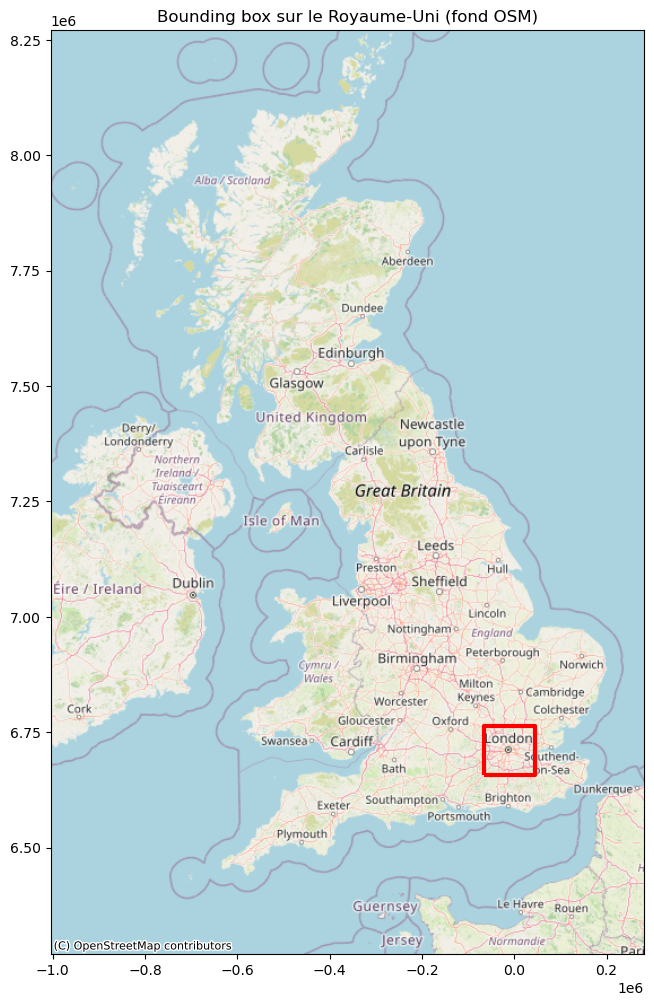

In [60]:

#Bounding box to test (can be modified)
minx, miny = -0.6, 51.2
maxx, maxy = 0.4, 51.8

bbox_poly = box(minx, miny, maxx, maxy)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326")

uk_minx, uk_miny = -8.5, 49.5
uk_maxx, uk_maxy = 2.0, 59.0

uk_poly = box(uk_minx, uk_miny, uk_maxx, uk_maxy)
uk_gdf = gpd.GeoDataFrame(geometry=[uk_poly], crs="EPSG:4326")

uk_web = uk_gdf.to_crs(3857)
bbox_web = bbox_gdf.to_crs(3857)

# --- 4) Affichage ---
fig, ax = plt.subplots(figsize=(10, 12))

# UK rectangle (juste pour cadrer la carte)
uk_web.boundary.plot(ax=ax, linewidth=0)

# bounding box rouge
bbox_web.boundary.plot(ax=ax, color="red", linewidth=3)

# fond de carte OSM
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Bounding box sur le Royaume-Uni (fond OSM)")
plt.show()


## Subgraph

In [61]:
lat_min, lat_max = 51.2, 51.8
lon_min, lon_max = -0.6, 0.4

nodes_to_keep = []

for n, d in G.nodes(data=True):

    lat = d.get("lat")
    lon = d.get("lon")

    if lat is not None and lon is not None:

        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            nodes_to_keep.append(n)

G_london = G.subgraph(nodes_to_keep).copy()

In [62]:
largest_cc = max(nx.connected_components(G_london), key=len)

G_london = G_london.subgraph(largest_cc).copy()

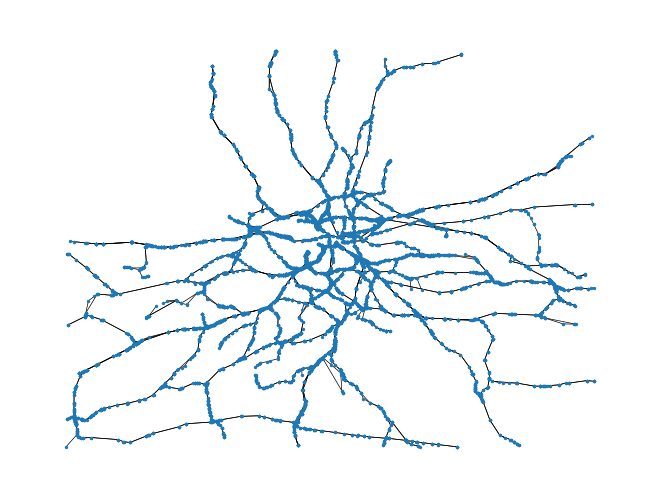

In [63]:
pos = {
    n: (d["lon"], d["lat"])
    for n, d in G_london.nodes(data=True)
    if "lon" in d and "lat" in d
}

nx.draw(
    G_london,
    pos,
    node_size=2,
    width=0.5,
    with_labels=False
)

In [64]:
print("Nodes :", G_london.number_of_nodes())
print("Edges :", G_london.number_of_edges())

Nodes : 10095
Edges : 10454


In [65]:
print(nx.number_connected_components(G_london))

1


In [66]:
degrees = [d for n, d in G_london.degree()]

avg_degree = sum(degrees) / len(degrees)

print(avg_degree)

2.071124318969787


In [67]:
list(G_final.nodes(data=True))[:2]

[((1.1454283, 51.2592228),
  {'type': 'osm_point', 'lon': 1.1454283, 'lat': 51.2592228}),
 ((-2.5807156, 51.4484134),
  {'type': 'osm_point', 'lon': -2.5807156, 'lat': 51.4484134})]

In [68]:
list(G_london.edges(data=True))[:2]

[((-0.0988616, 51.4973916),
  (-0.0985157, 51.4951534),
  {'distance': 0.15536053947488085,
   'maxspeed': 60.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 2,
   'usage': 'main',
   'elr': 'HHH'}),
 ((-0.0988616, 51.4973916),
  (-0.099215, 51.4980146),
  {'distance': 0.04565088254080461,
   'maxspeed': 60.0,
   'loading_gauge': 7.0,
   'electrified': '3rd_Rail',
   'gauge': '1435',
   'tracks': 4,
   'usage': 'main',
   'elr': nan})]

# Add name and tiploc

In [69]:
valid_nodes = []
valid_coords = []

for n in G_london.nodes:
    if n in G.nodes:
        d = G.nodes[n]
        lon = d.get("lon")
        lat = d.get("lat")

        # garder uniquement les coordonnées finies
        if lon is not None and lat is not None and math.isfinite(lon) and math.isfinite(lat):
            valid_nodes.append(n)
            valid_coords.append([lon, lat])

valid_coords = np.array(valid_coords)
tree = cKDTree(valid_coords)

for _, row in df_name_loc.iterrows():
    lon = row["long"]
    lat = row["lat"]

    # ignorer les lignes invalides
    if lon is None or lat is None:
        continue
    if not (math.isfinite(lon) and math.isfinite(lat)):
        continue

    tiploc = row["tiploc"]
    name = row["name"]

    # nearest neighbour dans les nœuds valides
    dist, idx = tree.query([lon, lat])
    nearest_node = valid_nodes[idx]

    # ajouter les attributs dans G_london
    G_london.nodes[nearest_node]["tiploc"] = tiploc
    G_london.nodes[nearest_node]["name"] = name


In [70]:
count_tiploc = sum(
    1 for n, d in G_london.nodes(data=True)
    if "tiploc" in d
)

count_name = sum(
    1 for n, d in G_london.nodes(data=True)
    if "name" in d
)

print("Nœuds avec tiploc :", count_tiploc)
print("Nœuds avec name   :", count_name)
print("Total nœuds       :", G_london.number_of_nodes())


Nœuds avec tiploc : 460
Nœuds avec name   : 463
Total nœuds       : 10095


## Add stanox

In [71]:
df_STAN_TIP.columns

Index(['id', 'NLC', 'STANOX', 'TIPLOC', '3ALPHA', 'UIC', 'NLCDESC',
       'NLCDESC16'],
      dtype='object')

In [72]:
tiploc_to_stanox = {
    row["TIPLOC"]: row["STANOX"]
    for _, row in df_STAN_TIP.iterrows()
    if isinstance(row["TIPLOC"], str)
}

count_added = 0

for n, d in G_london.nodes(data=True):
    tiploc = d.get("tiploc")
    if tiploc in tiploc_to_stanox:
        G_london.nodes[n]["stanox"] = tiploc_to_stanox[tiploc]
        count_added += 1

print("STANOX added :", count_added)


STANOX added : 457


In [73]:
count_stanox = sum(
    1 for _, d in G_london.nodes(data=True)
    if "stanox" in d
)

print("Nœuds avec stanox :", count_stanox)
print("Nœuds avec tiploc :", sum("tiploc" in d for _, d in G_london.nodes(data=True)))


Nœuds avec stanox : 462
Nœuds avec tiploc : 460


In [74]:
sample = [
    (n, {k: d[k] for k in ["lon", "lat", "tiploc", "name", "stanox"] if k in d})
    for n, d in G_london.nodes(data=True)
    if "tiploc" in d
][:10]

sample


[('ELMW',
  {'lon': 0.043594,
   'lat': 51.417435,
   'tiploc': 'ELMW',
   'name': 'Elmstead Woods',
   'stanox': '88468'}),
 ('BRNHRST',
  {'lon': 0.160885,
   'lat': 51.464798,
   'tiploc': 'BRNHRST',
   'name': 'Barnehurst',
   'stanox': '88422'}),
 ('DENMRKH',
  {'lon': -0.089475,
   'lat': 51.468243,
   'tiploc': 'DENMRKH',
   'name': 'Denmark Hill',
   'stanox': '87606'}),
 ('CNNB',
  {'lon': -0.091614,
   'lat': 51.548747,
   'tiploc': 'CNNB',
   'name': 'Canonbury',
   'stanox': '52048'}),
 ((0.1197351, 51.5667313),
  {'lon': 0.1197351,
   'lat': 51.5667313,
   'tiploc': 'GODMAYS',
   'name': 'Goodmayes',
   'stanox': '50412'}),
 ('FORESTH',
  {'lon': -0.053297,
   'lat': 51.438869,
   'tiploc': 'FORESTH',
   'name': 'Forest Hill',
   'stanox': '87627'}),
 ('LDYW',
  {'lon': -0.019445,
   'lat': 51.456291,
   'tiploc': 'LDYW',
   'name': 'Ladywell',
   'stanox': '88309'}),
 ('CRSHLTB',
  {'lon': -0.17023,
   'lat': 51.357117,
   'tiploc': 'CRSHLTB',
   'name': 'Carshalton Beech

## Analysis of the subgraph (London)

In [75]:
print("Nodes:", G_london.number_of_nodes())
print("Edges:", G_london.number_of_edges())
print("Number of components:", nx.number_connected_components(G_london))

Nodes: 10095
Edges: 10454
Number of components: 1


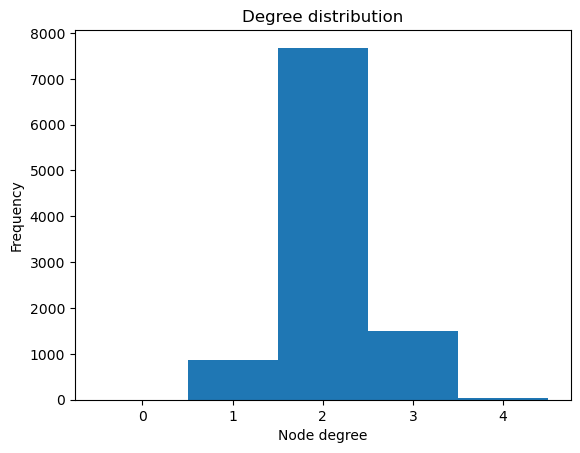

In [76]:
degrees = [d for n, d in G_london.degree()]

plt.hist(degrees, bins=range(max(degrees)+2), align='left')

plt.xlabel("Node degree")
plt.ylabel("Frequency")
plt.title("Degree distribution")

plt.show()

In [77]:
top_degree = sorted(
    G_london.degree(),
    key=lambda x: x[1],
    reverse=True
)[:20]

for node, degree in top_degree:
    attrs = G_london.nodes[node]

    if "name" in attrs:
        display_name = attrs["name"]
    elif "tiploc" in attrs:
        display_name = attrs["tiploc"]
    else:
        display_name = "Unknown"

    print(f"{display_name} ({node}) : {degree}")

Unknown ((-0.0863657, 51.3861687)) : 4
Unknown ((-0.1149192, 51.4995671)) : 4
Unknown ((-0.0873369, 51.5200807)) : 4
Unknown ((-0.0613572, 51.550288)) : 4
Unknown ((-0.0145929, 51.4659457)) : 4
Unknown ((-0.0596597, 51.5470377)) : 4
Unknown ((0.0042518, 51.446856)) : 4
Unknown ((-0.1150438, 51.4971623)) : 4
Unknown ((0.0251778, 51.5098454)) : 4
Unknown ((-0.1149285, 51.4974397)) : 4
Unknown ((-0.4192922, 51.2918841)) : 4
Unknown ((-0.0054259, 51.5408142)) : 4
Unknown ((-0.1149876, 51.4971341)) : 4
Unknown ((-0.5619278, 51.4028783)) : 4
Unknown ((-0.1151909, 51.4969294)) : 4
Unknown ((-0.2554898, 51.5218732)) : 4
Unknown ((-0.1145392, 51.5005458)) : 4
Unknown ((-0.0807342, 51.5204417)) : 4
Unknown ((-0.243849, 51.5310575)) : 4
Unknown ((-0.1148597, 51.4995452)) : 4


In [78]:
station_nodes = [
    (node, degree)
    for node, degree in G_london.degree()
    if "name" in G_london.nodes[node]
]

top_degree = sorted(
    station_nodes,
    key=lambda x: x[1],
    reverse=True
)

for node, degree in top_degree:
    print(G_london.nodes[node]["name"], degree)

Hatch End 3
Upminster 3
Gerrards Cross 3
West Ruislip 3
Staines 3
Barnes 3
South Acton 3
Southall 3
Twickenham 3
Wembley Stadium 3
South Ruislip 3
Harringay 3
Radlett 3
Battersea Park 3
Slade Green 3
Goodmayes 2
West Drayton 2
Iver 2
London Marylebone 2
Emerson Park 2
Watford North 2
Oxted 2
South Hampstead 2
Wokingham 2
Kensal Rise 2
Harlow Mill 2
Tolworth 2
Hever 2
Bricket Wood 2
Broxbourne 2
Upper Holloway 2
Watford Junction 2
Streatham Hill 2
Hanwell 2
Enfield Town 2
Park Street 2
Dorking 2
Greenford 2
Rickmansworth 2
Sydenham 2
Angmering 2
London Euston 2
Northolt Park 2
Brookwood 2
Chadwell Heath 2
Hornsey 2
Surbiton 2
Earlswood (Surrey) 2
West Horndon 2
Hemel Hempstead 2
Grove Park 2
Alexandra Palace 2
Sundridge Park 2
Norwood Junction 2
How Wood 2
Woking 2
Chilworth 2
Harlesden 2
Brimsdown 2
Leigh (Kent) 2
St Helier 2
Clapham Junction 2
New Southgate 2
Chertsey 2
Bellingham 2
Dorking West 2
Stonebridge Park 2
Stratford International 2
Pulborough 2
Whitby 2
Acton Main Line 2
Den

## Betweenness centrality analysis

In [79]:
# bc = nx.betweenness_centrality(
#     G_london,
#     normalized=True
# )

In [80]:
# top_bc = sorted(
#     bc.items(),
#     key=lambda x: x[1],
#     reverse=True
# )

# for node, value in top_bc:
#     attrs = G_london.nodes[node]

#     display_name = display_name = (attrs.get("name") or attrs.get("tiploc") or "Unknown")

#     print(f"{display_name} ({node}) : {value}")

## Spread of gauges

In [81]:
gauges = []

for u, v, d in G_london.edges(data=True):
    gauges.append(d.get("loading_gauge"))

gauges_counts = pd.Series(gauges).value_counts(dropna=False)
print(gauges_counts)

7.0     5905
10.0    3576
6.0      487
NaN      343
8.0      132
9.0       11
Name: count, dtype: int64


## Spread of electrification

In [82]:
electrification = []

for u, v, d in G_london.edges(data=True):
    electrification.append(d.get("electrified"))

elec_counts = pd.Series(electrification).value_counts(dropna=False)
print(elec_counts)

3rd_Rail    5895
Overhead    3864
No           352
None         343
Name: count, dtype: int64


## Save subgraph

In [83]:
#Optionnal
with open("subgraph.gpickle", "wb") as f:
    pickle.dump(G_london, f)

## Load subgraph

In [84]:
#Optionnal
with open("subgraph.gpickle", "rb") as f:
    G_london = pickle.load(f)

## Network resilience

## Analysis with closeness centrality

In [85]:
closeness_globale = nx.closeness_centrality(G_london, distance='length')
nx.set_node_attributes(G_london, closeness_globale, 'closeness')
top_5_topo = sorted(closeness_globale.items(), key=lambda x: x[1], reverse=True)[:20]

In [86]:
top_topo = sorted(closeness_globale.items(), key=lambda x: x[1], reverse=True)[:20]

In [87]:
print("\n--- Top hubs ---")
for i, (node, score) in enumerate(top_topo, 1):
    node_data = G_london.nodes[node]
    
    lon, lat = node[0], node[1]
    
    tiploc = node_data.get('tiploc', 'Unknown')
    stanox = node_data.get('stanox', 'Unknown')
    nom = node_data.get('name')
    
    if nom:
        print(f"{i}: Gare: {nom} (STANOX: {stanox}) | Score: {score:.5f}")
    else:
        print(f"{i}: Unknown junction (TIPLOC: {tiploc} | STANOX: {stanox})", "Coordinates : ", (lat, lon), f"Score: {score:.5f}")


--- Top hubs ---
1: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.469214, -0.1019655) Score: 0.01149
2: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4688812, -0.102015) Score: 0.01148
3: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4680616, -0.1022069) Score: 0.01147
4: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4931499, -0.09897) Score: 0.01145
5: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4678385, -0.1022275) Score: 0.01145
6: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4692252, -0.1019618) Score: 0.01144
7: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4951428, -0.0983892) Score: 0.01143
8: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4987277, -0.0996115) Score: 0.01142
9: Unknown junction (TIPLOC: Unknown | STANOX: Unknown) Coordinates :  (51.4683305, -0.1021131) Sc

## Select a departing and terminating point

In [154]:
import networkx as nx
import ast
from Tool import resilience_edge, resilience_node

MAPPING_STANOX_GEO = {
    "51127": (-0.2522, 51.5244),  # Acton Wells Junction
    "52226": (-0.0111, 51.5436)   # Channelsea Junction
}

stanox_dep_cible = str(int(df_parcours_final['loc_stanox'].iloc[0])).strip()
stanox_arr_cible = str(int(df_parcours_final['loc_stanox'].iloc[-1])).strip()

print(f"STANOX begin : {stanox_dep_cible}")
print(f"STANOX end : {stanox_arr_cible}\n")

def trouver_noeud_le_plus_proche(graphe, coord_cible):
    def extraire_coordonnees(n):
        if isinstance(n, (tuple, list)) and len(n) >= 2:
            return float(n[0]), float(n[1])
        elif isinstance(n, str) and n.startswith('(') and n.endswith(')'):
            try:
                t = ast.literal_eval(n)
                return float(t[0]), float(t[1])
            except:
                pass

        data = graphe.nodes[n]
        return float(data.get('lon', 0)), float(data.get('lat', 0))

    return min(
        graphe.nodes(), 
        key=lambda n: (extraire_coordonnees(n)[0] - coord_cible[0])**2 + (extraire_coordonnees(n)[1] - coord_cible[1])**2
    )


coord_dep = MAPPING_STANOX_GEO[stanox_dep_cible]
coord_arr = MAPPING_STANOX_GEO[stanox_arr_cible]
    
origine = trouver_noeud_le_plus_proche(G_london, coord_dep)
destination = trouver_noeud_le_plus_proche(G_london, coord_arr)
    
nom_ori = G_london.nodes[origine].get('name', 'West node')
nom_dest = G_london.nodes[destination].get('name', 'East node')
    
print(f"Origin id : {origine} ({nom_ori})")
print(f"Destination id : {destination} ({nom_dest})")

STANOX begin : 51127
STANOX end : 52226

Origin id : (-0.2535821, 51.5245475) (West node)
Destination id : (-0.011934, 51.5447023) (East node)


## Compute the shortest path

In [96]:
try:
    path = nx.shortest_path(G_london, source=origine, target=destination, weight="distance")
    
    initial_distance = nx.path_weight(G_london, path, weight="distance")
    
    print(f"Total distance : {initial_distance:.2f} miles)")
    print(f"Nodes encountered : {len(path)}")
    print(f"Edges encountered : {len(path) - 1}")

except nx.NetworkXNoPath:
    print("No available path")

Total distance : 48.43 miles)
Nodes encountered : 237
Edges encountered : 236


## Simulate an incident by removing an edge

In [101]:
try:
    path = nx.shortest_path(G_london, source=origine, target=destination, weight="distance")
    distance_initial = nx.path_weight(G_london, path, weight="distance")

    # FIX: Calculate the middle index of the path dynamically
    mid_index = len(path) // 2
    
    node_A = path[mid_index]
    node_B = path[mid_index + 1]
    
    name_A = G_london.nodes[node_A].get('name', str(node_A))
    name_B = G_london.nodes[node_B].get('name', str(node_B))
    
    print("\nIncident takes place between :")
    print(f"{name_A}")
    print(f"And   : {name_B}")

    G_disrupted = G_london.copy()
    
    G_disrupted.remove_edge(node_A, node_B)
    print(f"\nEdge deleted between {name_A} and {name_B}.")
    
except Exception as e:
    print("Error:", e)


Incident takes place between :
(-0.0229881, 51.4676843)
And   : (-0.0222779, 51.4678815)

Edge deleted between (-0.0229881, 51.4676843) and (-0.0222779, 51.4678815).


## Find alternative paths

In [102]:
from itertools import islice

K_ALTERNATIVE_PATHS = 5

try:
    path_generator = nx.shortest_simple_paths(G_disrupted, source=origine, target=destination, weight="distance")
    
    k_paths = list(islice(path_generator, K_ALTERNATIVE_PATHS))
    
    print(f"{len(k_paths)} paths were extracted\n")
    
    for i, p in enumerate(k_paths):
        dist_detour = nx.path_weight(G_disrupted, p, weight="distance")
        
        print(f"Path N°{i+1} :")
        print(f"Total distance : {dist_detour:.2f} miles")
        print(f"Difference with the initial trip : +{dist_detour - distance_initiale:.2f} miles\n")

except nx.NetworkXNoPath:
    print("Any other path exists")

5 paths were extracted

Path N°1 :
Total distance : 48.50 miles
Difference with the initial trip : +0.06 miles

Path N°2 :
Total distance : 48.50 miles
Difference with the initial trip : +0.07 miles

Path N°3 :
Total distance : 48.51 miles
Difference with the initial trip : +0.08 miles

Path N°4 :
Total distance : 48.51 miles
Difference with the initial trip : +0.08 miles

Path N°5 :
Total distance : 48.56 miles
Difference with the initial trip : +0.12 miles



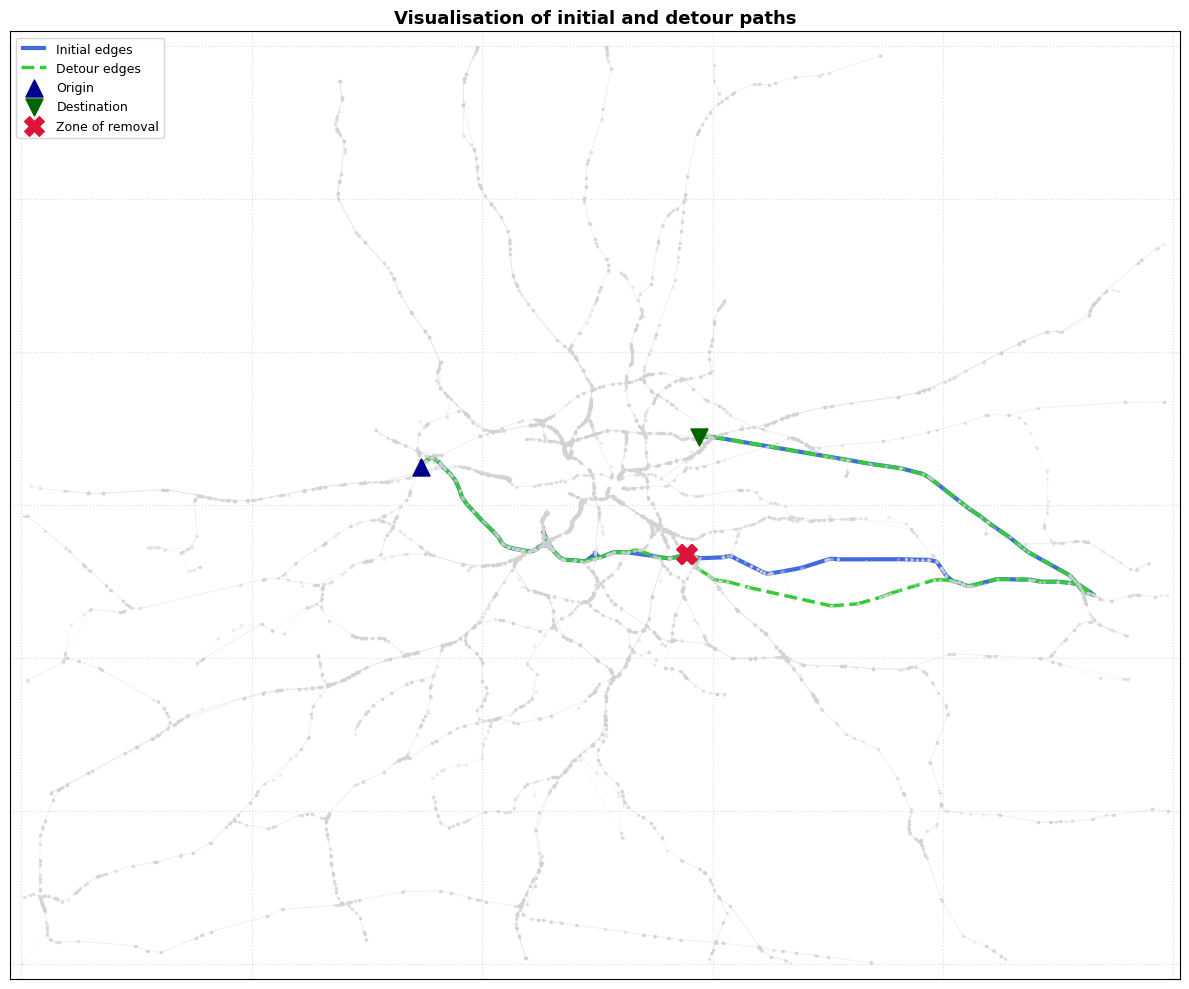

In [104]:
plt.figure(figsize=(12, 10))

pos = {}
for node, data in G_london.nodes(data=True):
    try:
        pos[node] = (float(data.get('lon', 0)), float(data.get('lat', 0)))
    except (ValueError, TypeError):
        pos[node] = (0.0, 0.0)

nx.draw_networkx_nodes(G_london, pos, node_size=2, node_color="lightgray", alpha=0.3)
nx.draw_networkx_edges(G_london, pos, edge_color="gainsboro", width=0.5, alpha=0.3)

edges_initial = [(path[i], path[i+1]) for i in range(len(path)-1)]
nx.draw_networkx_edges(G_london, pos, edgelist=edges_initial, edge_color="royalblue", width=3, label="Initial edges")
#nx.draw_networkx_nodes(G_london, pos, nodelist=path, node_size=25, node_color="royalblue", label="Initial nodes")

path_alt = k_paths[0]
edges_alt = [(path_alt[i], path_alt[i+1]) for i in range(len(path_alt)-1)]
nx.draw_networkx_edges(G_london, pos, edgelist=edges_alt, edge_color="limegreen", width=2.5, style="dashed", label="Detour edges")
#nx.draw_networkx_nodes(G_london, pos, nodelist=path_alt, node_size=15, node_color="limegreen", alpha=0.8, label="Detour nodes")

nx.draw_networkx_nodes(G_london, pos, nodelist=[origine], node_size=150, node_color="darkblue", node_shape="^", label="Origin")
nx.draw_networkx_nodes(G_london, pos, nodelist=[destination], node_size=150, node_color="darkgreen", node_shape="v", label="Destination")
nx.draw_networkx_nodes(G_london, pos, nodelist=[node_A, node_B], node_size=200, node_color="crimson", node_shape="X", label="Zone of removal")

lons = [p[0] for p in pos.values() if p != (0.0, 0.0)]
lats = [p[1] for p in pos.values() if p != (0.0, 0.0)]
if lons and lats:
    plt.xlim(min(lons) - 0.01, max(lons) + 0.01)
    plt.ylim(min(lats) - 0.01, max(lats) + 0.01)

plt.title("Visualisation of initial and detour paths", fontsize=13, fontweight="bold")
plt.legend(loc="upper left", scatterpoints=1, fontsize=9)
plt.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()

## Node resilience analysis

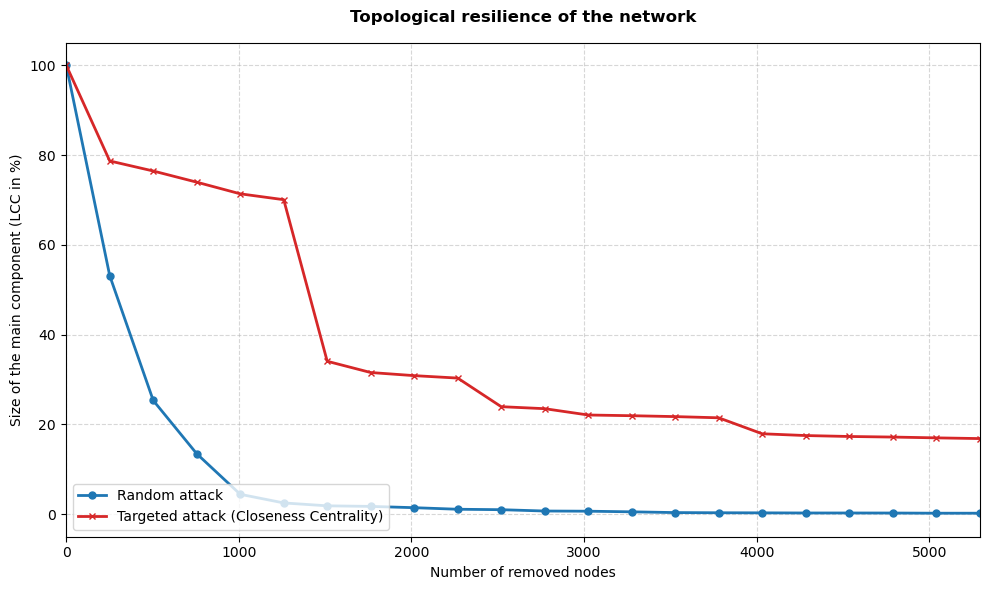

In [130]:
N_total = len(G_london.nodes())

max_noeuds_a_retirer = int(N_total * 0.50)
pas_voulise = int(max_noeuds_a_retirer / 20)

X, y_rand, y_target = resilience_node(G_london, max_retrait=max_noeuds_a_retirer, pas=pas_voulise)

plt.figure(figsize=(10, 6))

plt.plot(X, y_rand, label='Random attack', color='tab:blue', linewidth=2, marker='o', markersize=5)
plt.plot(X, y_target, label='Targeted attack (Closeness Centrality)', color='tab:red', linewidth=2, marker='x', markersize=5)

plt.title("Topological resilience of the network", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Number of removed nodes", fontsize=10)
plt.ylabel("Size of the main component (LCC in %)", fontsize=10)
plt.ylim(-5, 105)
plt.xlim(-2, max(X) + 2)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Edge resilience analysis

Number of edges in the network : 10454


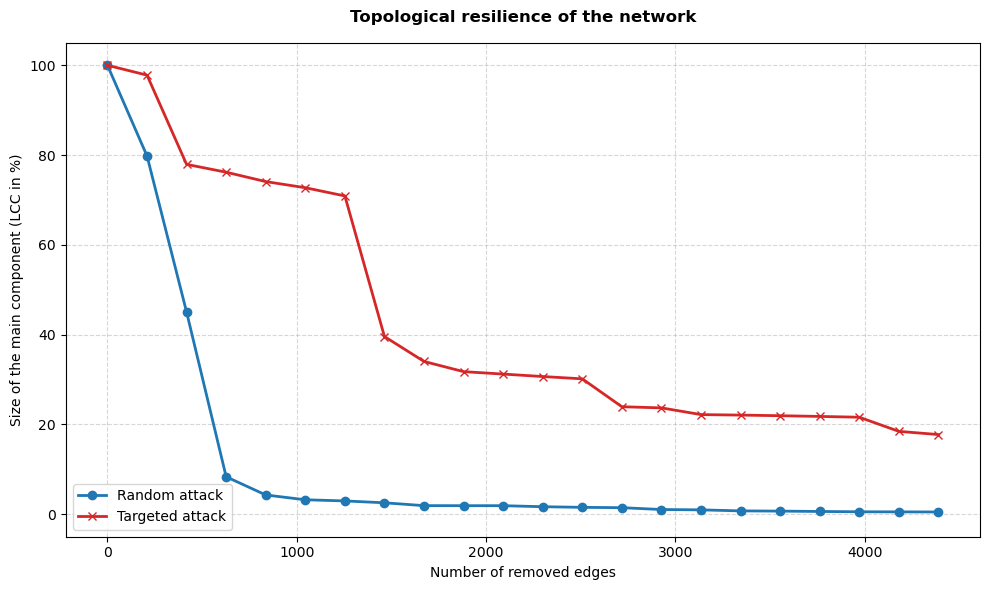

In [131]:
E_total = len(G_london.edges())
print(f"Number of edges in the network : {E_total}")

max_edges_a_retirer = int(E_total * 0.40)
pas_edges = int(max_edges_a_retirer / 20)

# 3. Calcul
X_e, y_rand_e, y_target_e = resilience_edge(G_london, max_retrait_edges=max_edges_a_retirer, pas=pas_edges)

plt.figure(figsize=(10, 6))

plt.plot(X_e, y_rand_e, label='Random attack', color='tab:blue', linewidth=2, marker='o')
plt.plot(X_e, y_target_e, label='Targeted attack', color='tab:red', linewidth=2, marker='x')

plt.title("Topological resilience of the network", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Number of removed edges", fontsize=10)
plt.ylabel("Size of the main component (LCC in %)", fontsize=10)
plt.ylim(-5, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

## Test with shortest path available

In [155]:
import networkx as nx
import random

closeness_dict = nx.closeness_centrality(G_london, distance='length')
edges_scores = {(u, v): closeness_dict.get(u, 0) + closeness_dict.get(v, 0) for u, v in G_london.edges()}

top_edge_target = max(edges_scores, key=edges_scores.get)

top_edge_random = random.choice(list(G_london.edges()))

graph_nodes = list(G_london.nodes())
origin = origine
#destination = graph_nodes[-1]
graph_nodes
print(f"ROUTE RESILIENCE TEST")
print(f"Origin : {G_london.nodes[origin].get('name', origin)}")
print(f"Destination : {G_london.nodes[destination].get('name', destination)}")

try:
    path_initial = nx.shortest_path(G_london, source=origin, target=destination, weight="distance")
    # CHANGED: Using nx.path_weight
    dist_initial = nx.path_weight(G_london, path_initial, weight="distance")
    print(f" Nominal route : {len(path_initial)} stations (Distance : {dist_initial:.2f} miles)")
except nx.NetworkXNoPath:
    for n1 in graph_nodes[:10]:
        for n2 in graph_nodes[-10:]:
            if nx.has_path(G_london, n1, n2):
                origin, destination = n1, n2
                break
    path_initial = nx.shortest_path(G_london, source=origin, target=destination, weight="distance")
    # CHANGED: Using nx.path_weight
    dist_initial = nx.path_weight(G_london, path_initial, weight="distance")
    print(f" Nominal route (adjusted) : {len(path_initial)} stations (Distance : {dist_initial:.2f} miles)")

#Random
G_rand = G_london.copy()
G_rand.remove_edge(*top_edge_random)
print(f"\nRandom Edge removed {top_edge_random}")

try:
    path_rand = nx.shortest_path(G_rand, source=origin, target=destination, weight="distance")
    # CHANGED: Using nx.path_weight
    dist_rand = nx.path_weight(G_rand, path_rand, weight="distance")
    print(f" -> New path possible ! New distance : {dist_rand:.2f} miles (Diff : +{dist_rand - dist_initial:.2f} miles)")
except nx.NetworkXNoPath:
    print(" -> The path is broken by this random removal !")

#Target
G_target = G_london.copy()
G_target.remove_edge(*top_edge_target)
print(f"\nHighly central edge removed (targeted) {top_edge_target}")

try:
    path_target = nx.shortest_path(G_target, source=origin, target=destination, weight="distance")
    dist_target = nx.path_weight(G_target, path_target, weight="distance")
    print(f"New path possible ! New distance : {dist_target:.2f} miles (Diff : +{dist_target - dist_initial:.2f} miles)")
except nx.NetworkXNoPath:
    print("The path is totally broken by the targeted removal !")

ROUTE RESILIENCE TEST
Origin : (-0.2535821, 51.5245475)
Destination : (-0.011934, 51.5447023)
 Nominal route : 237 stations (Distance : 48.43 miles)

Random Edge removed ((-0.4490181, 51.5070376), (-0.473994, 51.5099174))
 -> New path possible ! New distance : 48.43 miles (Diff : +0.00 miles)

Highly central edge removed (targeted) ((-0.1019655, 51.469214), (-0.102015, 51.4688812))
New path possible ! New distance : 48.47 miles (Diff : +0.04 miles)


In [178]:
#origin = list(G_london.nodes())[0]
#destination = list(G_london.nodes())[-1]

path = nx.shortest_path(G_london, source=origin, target=destination, weight="distance")
dist_initial = nx.shortest_path_length(G_london, source=origin, target=destination, weight="distance")
print(f"Initial distance : {dist_initial:.2f}")

middle_dis = len(path) // 2
u, v = path[middle_dis], path[middle_dis + 1]
print(f"Track disruption between {u} and {v}")

G_disrupted = G_london.copy()
G_disrupted.remove_edge(u, v)

try:
    new_path = nx.shortest_path(G_disrupted, source=origin, target=destination, weight="distance")
    dist_final = nx.shortest_path_length(G_disrupted, source=origin, target=destination, weight="distance")
    print(f"New distance after rerouting : {dist_final:.2f} (Surplus : {dist_final - dist_initial:.2f})")
except nx.NetworkXNoPath:
    print("The route is completely severed, no alternative path available !")

Initial distance : 48.43
Track disruption between (-0.0229881, 51.4676843) and (-0.0222779, 51.4678815)
New distance after rerouting : 48.50 (Surplus : 0.06)


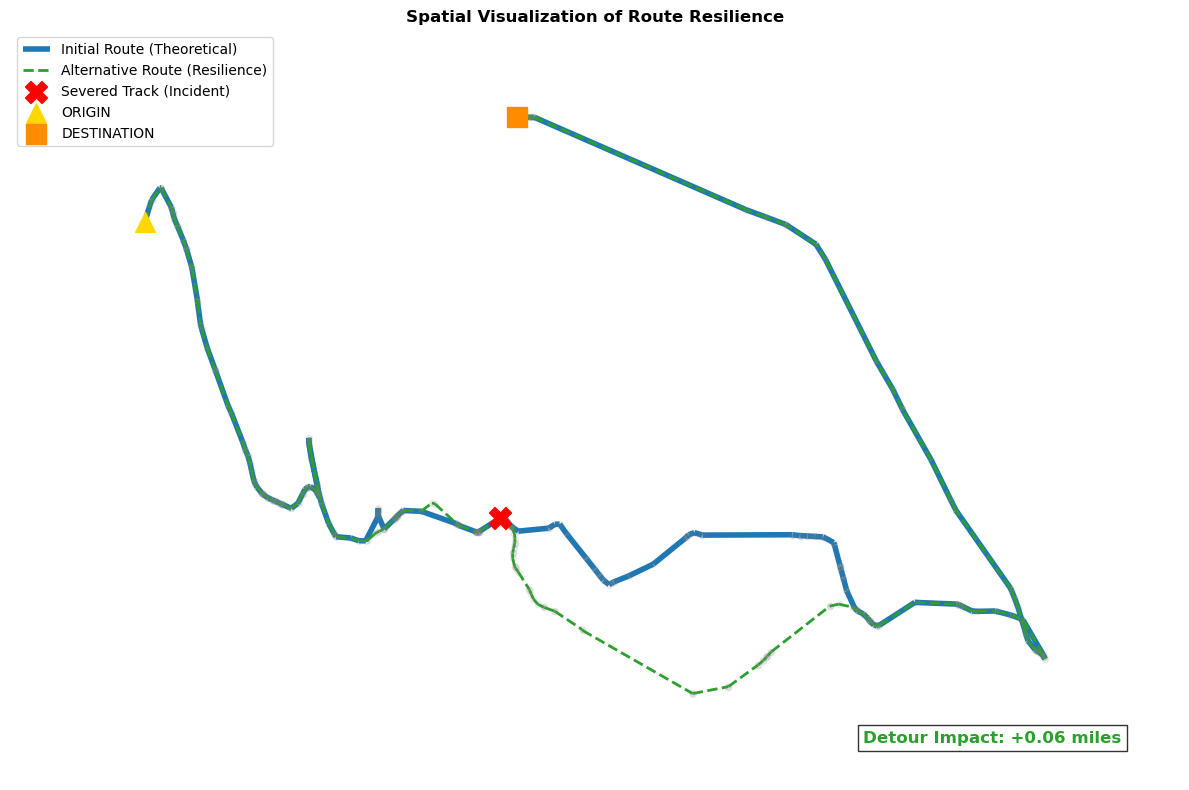

In [181]:
# --- 1. CALCUL DE L'INCIDENT AU MILIEU ET DU DÉTOUR ---
index_milieu = len(path) // 2
u, v = path[index_milieu], path[index_milieu + 1]

G_disrupted = G_london.copy()
# Sécurité pour supprimer l'arête peu importe son sens d'enregistrement
if G_disrupted.has_edge(u, v):
    G_disrupted.remove_edge(u, v)
elif G_disrupted.has_edge(v, u):
    G_disrupted.remove_edge(v, u)

try:
    # Retour à ton calcul d'origine
    new_path = nx.shortest_path(G_disrupted, source=origin, target=destination, weight="distance")
except nx.NetworkXNoPath:
    new_path = None


# --- 2. BLOC DE CARTOGRAPHIE ---
plt.figure(figsize=(12, 8))
pos = {node: node for node in G_london.nodes()}

nearby_nodes = set(path)
if new_path:
    nearby_nodes.update(new_path)

# Optionnel : Pour enlever l'effet de ligne droite vide du détour "louche", 
# on affiche TOUTES les gares d'arrière-plan de la zone en gris clair
sub_graph_local = G_london.subgraph(nearby_nodes)
nx.draw_networkx_nodes(sub_graph_local, pos, node_size=20, node_color='gray', alpha=0.1)
nx.draw_networkx_edges(sub_graph_local, pos, edge_color='gainsboro', alpha=0.2)

# 1. Dessin du trajet initial (Bleu)
path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(G_london, pos, edgelist=path_edges, edge_color='tab:blue', width=4, label='Initial Route (Theoretical)')

# 2. Dessin du détour (Vert)
if new_path:
    new_path_edges = list(zip(new_path[:-1], new_path[1:]))
    nx.draw_networkx_edges(G_london, pos, edgelist=new_path_edges, edge_color='tab:green', width=2, style='--', label='Alternative Route (Resilience)')

# 3. CRUCIAL : On dessine un énorme point rouge (X) à l'emplacement de la coupure pour qu'il soit bien visible
incident_x = pos[u][0]
incident_y = pos[u][1]
plt.scatter(incident_x, incident_y, color='red', s=250, marker='X', zorder=5, label='Severed Track (Incident)')

# 4. Origine et Destination
nx.draw_networkx_nodes(G_london, pos, nodelist=[origin], node_size=200, node_color='gold', node_shape='^', label='ORIGIN')
nx.draw_networkx_nodes(G_london, pos, nodelist=[destination], node_size=200, node_color='darkorange', node_shape='s', label='DESTINATION')

# Zoom automatique
all_x = [pos[n][0] for n in nearby_nodes]
all_y = [pos[n][1] for n in nearby_nodes]
margin_x = (max(all_x) - min(all_x)) * 0.15 if max(all_x) != min(all_x) else 1
margin_y = (max(all_y) - min(all_y)) * 0.15 if max(all_y) != min(all_y) else 1
plt.xlim(min(all_x) - margin_x, max(all_x) + margin_x)
plt.ylim(min(all_y) - margin_y, max(all_y) + margin_y)

# Ajout du texte d'impact que tu as fourni
if 'dist_final' in locals() and 'dist_initial' in locals():
    surplus = dist_final - dist_initial
    plt.text(0.95, 0.05, f"Detour Impact: +{surplus:.2f} miles", 
             transform=plt.gca().transAxes, ha='right', fontsize=12, 
             fontweight='bold', color='tab:green', bbox=dict(facecolor='white', alpha=0.8))

plt.title("Spatial Visualization of Route Resilience", fontsize=12, fontweight='bold')
plt.legend(loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
TRAIN_GAUGE = "W10"
TRAIN_TRACTION = "Diesel"


GAUGE_HIERARCHY = {"W6a": 1, "W7": 2, "W8": 3, "W9": 4, "W10": 5, "W12": 6}
G_restricted = G_london.copy()

disruption_index = len(path) // 2
u_cut, v_cut = path[disruption_index], path[disruption_index + 1]
if G_restricted.has_edge(u_cut, v_cut):
    G_restricted.remove_edge(u_cut, v_cut)

edges_to_remove = []
for u, v, edge_data in G_restricted.edges(data=True):
    #Loading gauge check
    gauge = edge_data.get("loading_gauge", "W6a")
    gauge_ok = GAUGE_HIERARCHY.get(gauge, 1) >= GAUGE_HIERARCHY.get(TRAIN_GAUGE, 5)
    
    #Electrification check
    electrification = edge_data.get("electrified", True)
    is_electrified = electrification not in [False, "N", "No", "None"]
    traction_ok = True if TRAIN_TRACTION == "Diesel" else is_electrified
    
    if not (gauge_ok and traction_ok):
        edges_to_remove.append((u, v))

#Cleaning the graph by removing all unusable tracks
G_restricted.remove_edges_from(edges_to_remove)
print(f"{len(edges_to_remove)} incompatible tracks have been removed.")

try:
    contingency_route = nx.shortest_path(G_restricted, source=origin, target=destination, weight="distance")
    total_dist = nx.path_weight(G_restricted, contingency_route, weight="distance")
    
    print("\nCompatible route found !")
    print(f"   -> Total detour distance: {total_dist:.2f} miles")
    print(f"   -> Number of nodes : {len(contingency_route)} stations")

except nx.NetworkXNoPath:
    print("\nNo alternative route is possible.")

10453 incompatible tracks have been removed.

No alternative route is possible.


# Train movement data

In [89]:
movement1 = "data/4E24_TRUST2.csv"
df_movement_first = pd.read_csv(movement1)

In [90]:
df_movement_first.head()

,id,created_unix,msg_type,source_dev_id,user_id,original_data_source,msg_queue_timestamp,source_system_id,event_type,gbtt_timestamp,...,train_service_code,toc_id,loc_stanox,auto_expected,direction_ind,route,planned_event_type,next_report_stanox,line_ind,Datetime
0,652732363,1777628679,3,NaN,NaN,SMART,1777628678000,TRUST,DEPARTURE,NaN,...,54606070,9,51123,True,UP,1.0,DEPARTURE,51122.0,NaN,2026-05-01 10:44:00.000
1,652737063,1777629084,3,FQ42159,NaN,TOPS,1777629084000,TRUST,DEPARTURE,1.777632e+12,...,54606070,9,51127,False,NaN,NaN,DEPARTURE,51129.0,NaN,2026-05-01 10:37:00.000
2,652743586,1777629641,3,NaN,NaN,SMART,1777629640000,TRUST,DEPARTURE,NaN,...,54606070,9,51121,True,UP,1.0,DEPARTURE,51203.0,U,2026-05-01 11:00:00.000
3,652750813,1777630264,3,NaN,NaN,SMART,1777630263000,TRUST,ARRIVAL,NaN,...,54606070,9,51203,True,NaN,0.0,ARRIVAL,51311.0,NaN,2026-05-01 11:11:00.000
4,652751402,1777630312,3,NaN,NaN,SMART,1777630310000,TRUST,DEPARTURE,NaN,...,54606070,9,51203,True,UP,1.0,DEPARTURE,51311.0,U,2026-05-01 11:11:00.000


In [91]:
df_movement_first.columns

Index(['id', 'created_unix', 'msg_type', 'source_dev_id', 'user_id',
       'original_data_source', 'msg_queue_timestamp', 'source_system_id',
       'event_type', 'gbtt_timestamp', 'original_loc_stanox',
       'planned_timestamp', 'timetable_variation', 'original_loc_timestamp',
       'current_train_id', 'delay_monitoring_point', 'next_report_run_time',
       'reporting_stanox', 'actual_timestamp', 'correction_ind',
       'event_source', 'train_file_address', 'platform', 'division_code',
       'train_terminated', 'train_id', 'offroute_ind', 'variation_status',
       'train_service_code', 'toc_id', 'loc_stanox', 'auto_expected',
       'direction_ind', 'route', 'planned_event_type', 'next_report_stanox',
       'line_ind', 'Datetime'],
      dtype='object')

## Litle bit of cleaning

In [92]:
df_movement_first['Datetime'] = pd.to_datetime(df_movement_first['Datetime'])
df_movement_first['loc_stanox'] = df_movement_first['loc_stanox'].astype(str).str.strip().str.zfill(5)

df_train_clean = df_movement_first.dropna(subset=['loc_stanox', 'timetable_variation']).copy()
df_train_clean['loc_stanox'] = df_train_clean['loc_stanox'].astype(str).str.replace('.0', '', regex=False)
df_train_clean = df_train_clean.sort_values(by='Datetime')
df_parcours_train = df_train_clean[['Datetime', 'actual_timestamp', 'loc_stanox', 'next_report_stanox','timetable_variation', 'variation_status', 'event_type', 'planned_event_type', 'direction_ind', 'train_terminated', 'train_id']].copy()

In [93]:
df_parcours_final = df_parcours_train.sort_values(by='Datetime')
df_parcours_final['timetable_variation'] = np.where(df_parcours_final['variation_status'] == 'EARLY', df_parcours_final['timetable_variation'] * (-1), df_parcours_final['timetable_variation'])
df_parcours_final.head()

,Datetime,actual_timestamp,loc_stanox,next_report_stanox,timetable_variation,variation_status,event_type,planned_event_type,direction_ind,train_terminated,train_id
1,2026-05-01 10:37:00,1777631820000,51127,51129.0,-11,EARLY,DEPARTURE,DEPARTURE,NaN,False,514E24CH01
0,2026-05-01 10:44:00,1777632240000,51123,51122.0,-11,EARLY,DEPARTURE,DEPARTURE,UP,False,514E24CH01
2,2026-05-01 11:00:00,1777633200000,51121,51203.0,-1,EARLY,DEPARTURE,DEPARTURE,UP,False,514E24CH01
3,2026-05-01 11:11:00,1777633860000,51203,51311.0,0,ON TIME,ARRIVAL,ARRIVAL,NaN,False,514E24CH01
4,2026-05-01 11:11:00,1777633860000,51203,51311.0,0,ON TIME,DEPARTURE,DEPARTURE,UP,False,514E24CH01


In [94]:
print(df_parcours_final['variation_status'].value_counts())

variation_status
EARLY      274
LATE       139
ON TIME     85
Name: count, dtype: int64


## Data distribution

In [117]:
df_diag = df_parcours_final.copy()
df_diag['Datetime'] = pd.to_datetime(df_diag['Datetime'], errors='coerce')
df_diag['Date_Only'] = df_diag['Datetime'].dt.date

#Count how many rows exist for each unique day
daily_counts = df_diag['Date_Only'].value_counts().sort_index()

print("Number of records found per day:")
print(daily_counts.to_string())

#Check unique train IDs
unique_trains = df_diag['train_id'].unique()
print(f"Unique train_ids in this dataset: {len(unique_trains)}")
print(f"Train ID list: {unique_trains[:5]}")

Number of records found per day:
Date_Only
2026-05-01    94
2026-05-05    95
2026-05-06    95
2026-05-07    94
2026-05-08    96
2026-05-11    24
Unique train_ids in this dataset: 6
Train ID list: ['514E24CH01' '514E24CH05' '514E24CH06' '514E24CH07' '514E24CH08']


## Speed statistics

In [138]:
df_speed = df_parcours_final.copy()
df_speed['Datetime'] = pd.to_datetime(df_speed['Datetime'], errors='coerce')

df_speed = df_speed.sort_values(by=['train_id', 'Datetime'])

AVERAGE_INTER_STANOX_DISTANCE_MILES = 2.5

df_speed['next_datetime'] = df_speed.groupby('train_id')['Datetime'].shift(-1)
df_speed['delta_t_hours'] = (df_speed['next_datetime'] - df_speed['Datetime']).dt.total_seconds() / 3600.0

df_segments = df_speed[(df_speed['delta_t_hours'] > 0.0041) & (df_speed['delta_t_hours'] < 1.0)].copy()

df_segments['segment_speed_mph'] = AVERAGE_INTER_STANOX_DISTANCE_MILES / df_segments['delta_t_hours']

# Correction de la ligne problématique en gardant la structure d'origine
df_segments['segment_speed_mph'] = df_segments['segment_speed_mph'].clip(upper=80)
    
print(f"Overall average section speed  : {df_segments['segment_speed_mph'].mean():.1f} mph")
print(f"Maximum recorded section speed : {df_segments['segment_speed_mph'].max():.1f} mph")
print(f"Minimum recorded section speed : {df_segments['segment_speed_mph'].min():.1f} mph")

Overall average section speed  : 46.0 mph
Maximum recorded section speed : 80.0 mph
Minimum recorded section speed : 3.8 mph


## Speed distribution

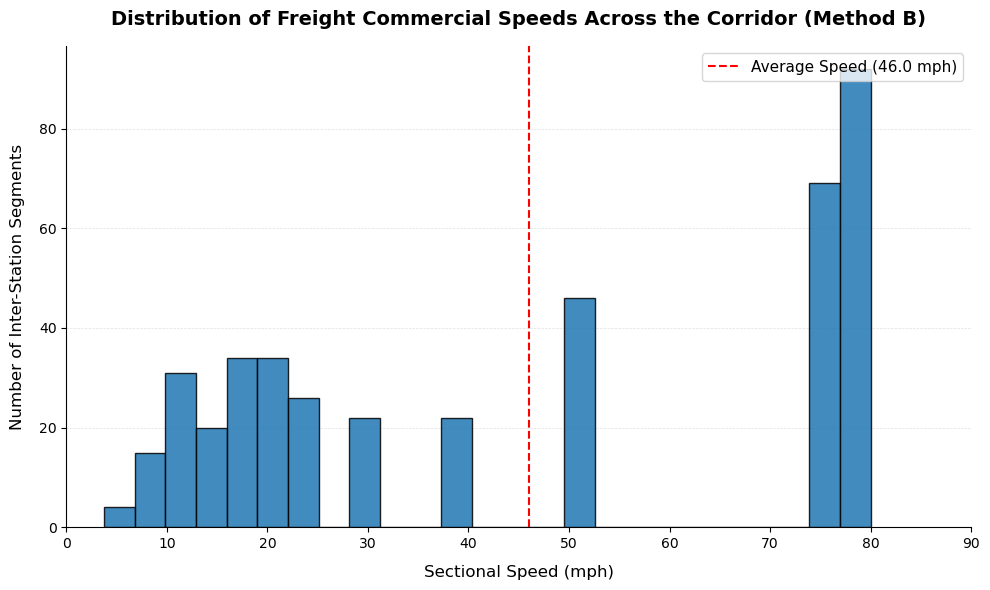

In [140]:
fig, ax = plt.subplots(figsize=(10, 6))

counts, bins, patches = ax.hist(
    df_segments['segment_speed_mph'], 
    bins=25, 
    color='#1f77b4',
    edgecolor='black',
    alpha=0.85
)

ax.set_title('Distribution of Freight Commercial Speeds Across the Corridor (Method B)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Sectional Speed (mph)', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Inter-Station Segments', fontsize=12, labelpad=10)

ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#e0e0e0', linestyle='--', linewidth=0.5)
ax.xaxis.grid(False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlim(0, 90)

mean_speed = df_segments['segment_speed_mph'].mean()
ax.axvline(
    mean_speed, 
    color='red', 
    linestyle='--', 
    linewidth=1.5, 
    label=f"Average Speed ({mean_speed:.1f} mph)"
)

# Add the legend
ax.legend(fontsize=11, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

In [141]:
train_edges = []

for _, row in df_parcours_final.iterrows():

    u = row["loc_stanox"]
    v = row["next_report_stanox"]

    if pd.notna(v):

        train_edges.append((u, int(v)))

print(len(train_edges))

493


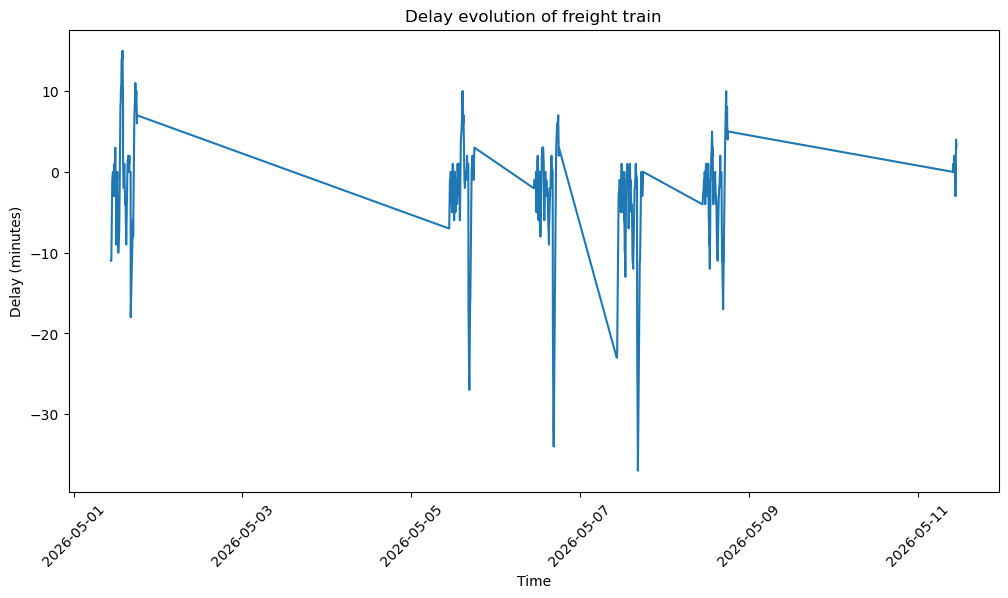

In [142]:
plt.figure(figsize=(12,6))

plt.plot(
    df_parcours_final["Datetime"],
    df_parcours_final["timetable_variation"]
)

plt.xlabel("Time")
plt.ylabel("Delay (minutes)")
plt.title("Delay evolution of freight train")

plt.xticks(rotation=45)

plt.show()

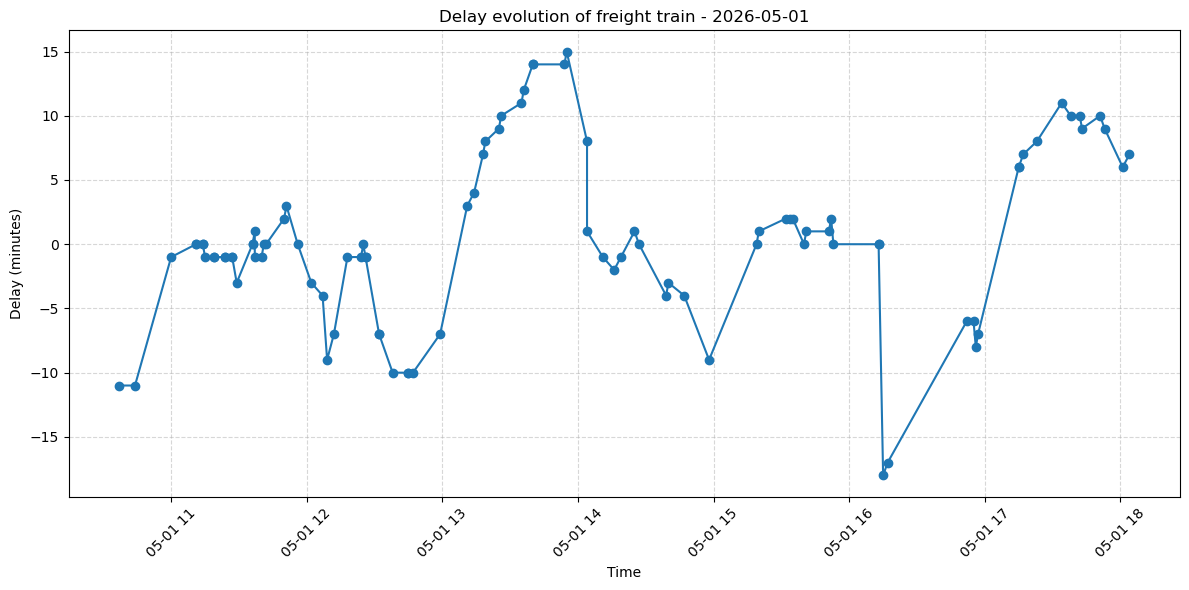

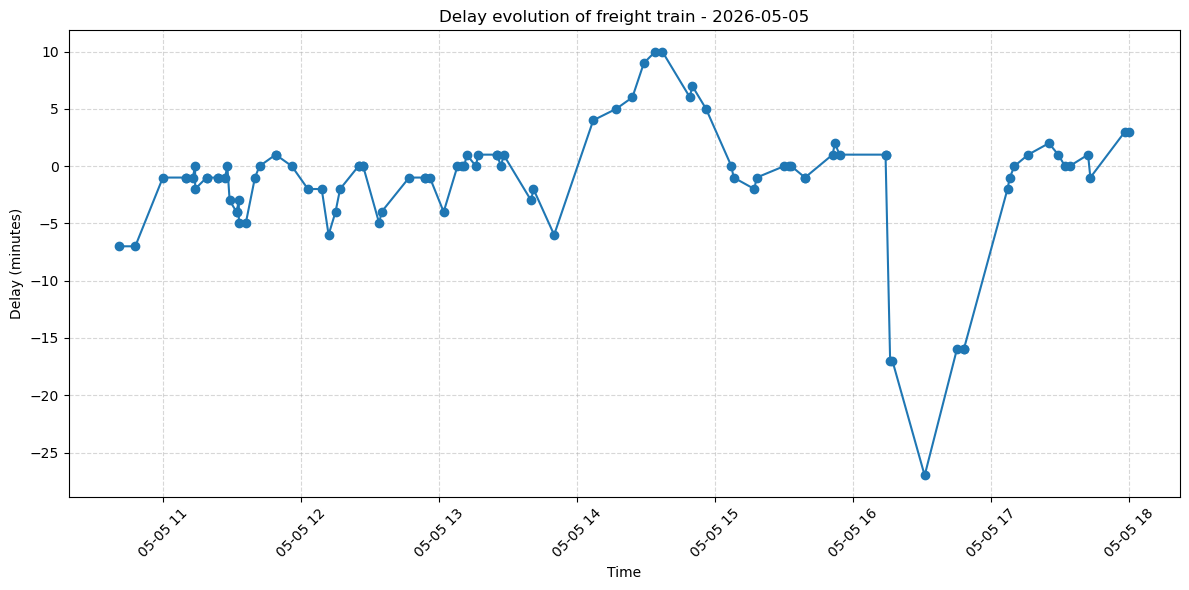

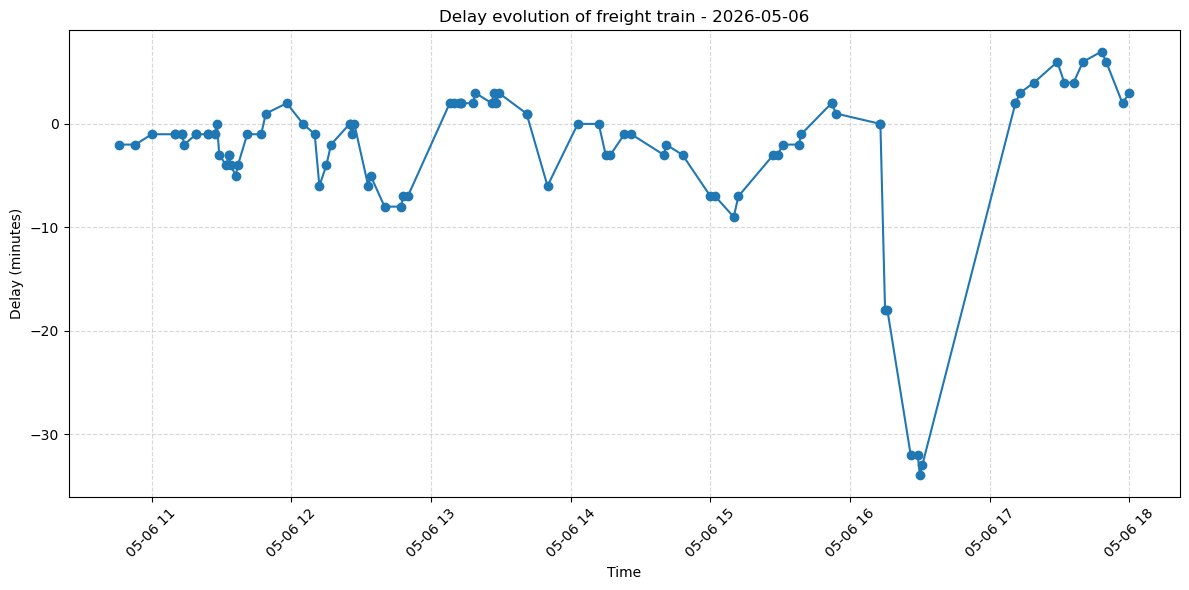

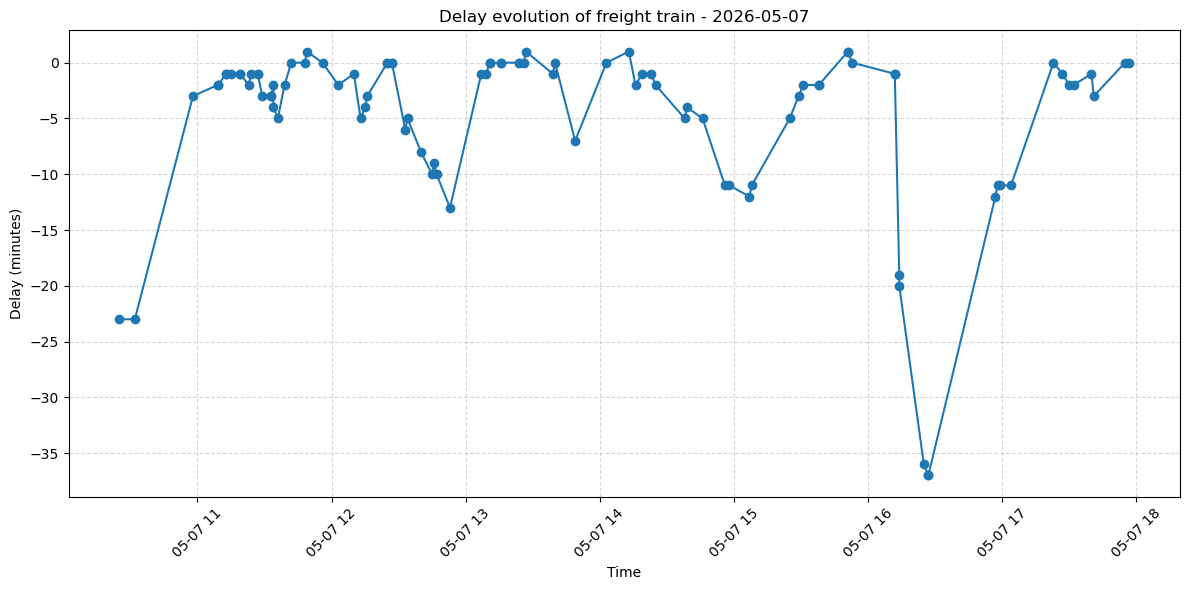

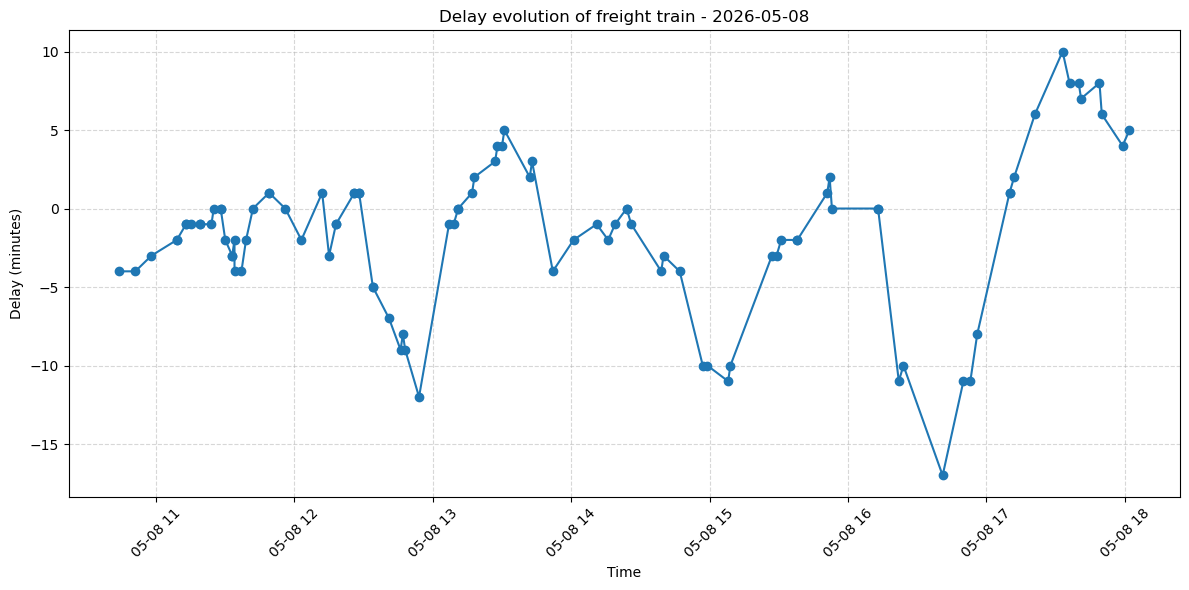

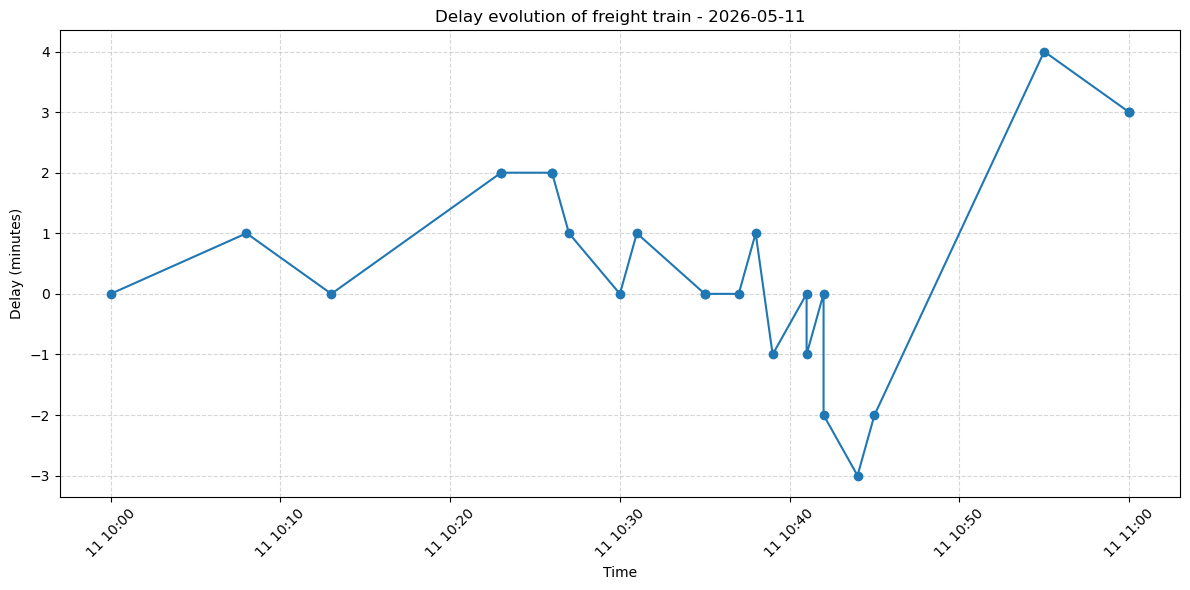

In [ ]:
df_parcours_final["Datetime"] = pd.to_datetime(df_parcours_final["Datetime"])

df_parcours_final["Jour"] = df_parcours_final["Datetime"].dt.date

for day, group in df_parcours_final.groupby("Jour"):
    plt.figure(figsize=(12, 6))
    
    plt.plot(
        group["Datetime"],
        group["timetable_variation"],
        marker='o',
        linestyle='-',
        color='tab:blue'
    )
    
    plt.xlabel("Time")
    plt.ylabel("Delay (minutes)")
    plt.title(f"Delay evolution of freight train - {day}")
    
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.show()

In [167]:
#origin = graph_nodes[0]
#destination = graph_nodes[-1]

print(origin in G_london)
print(destination in G_london)

True
True


In [168]:
#origin = list(G_london.nodes())[0]
#destination = list(G_london.nodes())[-1]

path = nx.shortest_path(
    G_london,
    source=origin,
    target=destination,
    weight="distance"
)

print(path)

[(-0.2535821, 51.5245475), (-0.2504785, 51.5276876), (-0.2493379, 51.5286841), (-0.2491942, 51.5287908), (-0.243849, 51.5310575), (-0.2432178, 51.5310551), (-0.2431002, 51.5310486), (-0.2364429, 51.5273282), (-0.236374, 51.5272444), (-0.2356885, 51.5264601), (-0.2354216, 51.5261594), (-0.2345351, 51.525191), (-0.2326452, 51.523821), (-0.2324099, 51.5236948), (-0.2287132, 51.5210625), (-0.2285847, 51.520956), (-0.2268546, 51.519539), (-0.2267246, 51.5194269), (-0.2265534, 51.5192796), (-0.2233878, 51.5160851), (-0.2230137, 51.5156186), (-0.2195598, 51.5096583), (-0.2193532, 51.5089952), (-0.2174927, 51.5050235), (-0.2167767, 51.5040835), (-0.2132006, 51.5004426), (-0.2082297, 51.4964096), (-0.2078794, 51.4961348), (-0.2076614, 51.4959526), (-0.1995315, 51.4892689), (-0.19751, 51.4879655), (-0.1901617, 51.4824024), (-0.1884248, 51.4809266), (-0.1883109, 51.4808388), (-0.1868395, 51.479791), (-0.1866783, 51.4796602), (-0.1853627, 51.4783555), (-0.1841373, 51.47667), (-0.1828033, 51.474962

In [169]:
total_distance = 0

for u, v in zip(path[:-1], path[1:]):

    total_distance += G_london[u][v].get("distance", 0)

print("Distance:", total_distance)

Distance: 48.431393361924094


In [170]:
gauges = []

for u, v in zip(path[:-1], path[1:]):

    g = G_london[u][v].get("loading_gauge")

    gauges.append(g)

print(gauges)

[6.0, 6.0, 6.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 6.0,

In [171]:
gauge_order = {
    "6.0": 1,
    "7.0": 2,
    "8.0": 3,
    "9.0": 4,
    "10.0": 5,
    "12.0": 6
}

valid_gauges = [str(g).strip() for g in gauges if str(g).strip() in gauge_order]

if valid_gauges:
    limiting_gauge = min(
        valid_gauges,
        key=lambda x: gauge_order[x]
    )
    print("Limiting gauge found:", limiting_gauge)
else:
    limiting_gauge = "W6"
    print("Aucune jauge valide trouvée sur ce tronçon. Valeur par défaut restrictive attribuée : W6")

Limiting gauge found: 6.0


In [211]:
TRAIN_GAUGE = "6.0"  #Options : "6.0", "7.0", "8.0", "9.0", "10.0", "12.0"
TRAIN_TRACTION = "Diesel" #Options: "Diesel", "Overhead", "3rd_Rail"
MIN_ACCEPTABLE_SPEED = 30

G_restricted = G_london.copy()

disruption_index = len(path) // 2
u_cut, v_cut = path[disruption_index], path[disruption_index + 1]
if G_restricted.has_edge(u_cut, v_cut):
    G_restricted.remove_edge(u_cut, v_cut)

# Complete dictionary to track all statistics and failures
block_reasons = {
    "Loading Gauge Constraints": 0,
    "Electrification / Traction Mismatch": 0,
    "Track Gauge Incompatibility": 0,
    "Low Speed Zones (< 40 mph)": 0,
    "Single Track Bottlenecks": 0
}

edges_to_remove = []
for u, v, edge_data in G_restricted.edges(data=True):
    # 1. Loading gauge check
    gauge = str(edge_data.get("loading_gauge", "6.0"))
    gauge_ok = gauge_order.get(gauge, 1) >= gauge_order.get(TRAIN_GAUGE, 5)
    if not gauge_ok:
        block_reasons["Loading Gauge Constraints"] += 1
    
    # 2. Electrification & Traction check
    electrification = str(edge_data.get("electrified", "No")).strip()
    is_electrified = electrification not in ["False", "N", "No", "None", "Unknown"]
    
    if TRAIN_TRACTION == "Diesel":
        traction_ok = True
    elif TRAIN_TRACTION == "Electrified":
        traction_ok = is_electrified
    elif TRAIN_TRACTION == "Overhead":
        traction_ok = "overhead" in electrification.lower() or "ohle" in electrification.lower()
    elif TRAIN_TRACTION == "3rd_Rail":
        traction_ok = "3rd_rail" in electrification.lower() or "third_rail" in electrification.lower()
    else:
        traction_ok = False
        
    if not traction_ok:
        block_reasons["Electrification / Traction Mismatch"] += 1
        
    # 3. Track Gauge Check (Standard UK rail gauge is 1435mm)
    track_gauge = str(edge_data.get("gauge", "1435"))
    track_gauge_ok = (track_gauge == "1435")
    if not track_gauge_ok:
        block_reasons["Track Gauge Incompatibility"] += 1
        
    # 4. Max Speed Check (Logs slow tracks under the limit)
    max_speed = edge_data.get("maxspeed", 60.0)
    if max_speed < MIN_ACCEPTABLE_SPEED:
        block_reasons["Low Speed Zones (< 40 mph)"] += 1

    # 5. Track Capacity Check (Logs single track bottlenecks)
    tracks_count = edge_data.get("tracks", 2)
    if tracks_count == 1:
        block_reasons["Single Track Bottlenecks"] += 1
    
    # Final gatekeeper: Remove edge ONLY if it fails physical showstoppers
    if not (gauge_ok and traction_ok and track_gauge_ok):
        edges_to_remove.append((u, v))

# Cleaning the graph by removing all unusable tracks
G_restricted.remove_edges_from(edges_to_remove)

# Data Analysis Reporting
print(f"Type of energy : {TRAIN_TRACTION}")
print(f"{len(edges_to_remove)} incompatible tracks have been removed.")
print("\nBreakdown of infrastructure issues found :\n")
for criterion, count in block_reasons.items():
    if "Constraints" in criterion or "Mismatch" in criterion or "Incompatibility" in criterion:
        status = "" if count > 0 else "Passed"
        label = "-> Path not available" if count > 0 else ""
    else:
        status = "" if count > 0 else "None"
        label = "Caution" if count > 0 else ""
        
    print(f"   -> {criterion}: ({count} tracks incompatible)")
print("\n=================================================================")

try:
    contingency_route = nx.shortest_path(G_restricted, source=origin, target=destination, weight="distance")
    total_dist = nx.path_weight(G_restricted, contingency_route, weight="distance")
    
    print("\nCompatible route found :\n")
    print(f"   -> Total detour distance: {total_dist:.2f} miles")
    print(f"   -> Number of nodes : {len(contingency_route)} stations")

except nx.NetworkXNoPath:
    print(f"\nNo alternative route is possible for a {TRAIN_TRACTION} train.")

Type of energy : Diesel
102 incompatible tracks have been removed.

Breakdown of infrastructure issues found :

   -> Loading Gauge Constraints: (0 tracks incompatible)
   -> Electrification / Traction Mismatch: (0 tracks incompatible)
   -> Track Gauge Incompatibility: (102 tracks incompatible)
   -> Low Speed Zones (< 40 mph): (1490 tracks incompatible)
   -> Single Track Bottlenecks: (1455 tracks incompatible)


Compatible route found :

   -> Total detour distance: 48.50 miles
   -> Number of nodes : 228 stations
